## Three Specialized Models: Deep3DCNN, LUNA3DCNN, and CXRClassifier

Three specialized models, each trained and evaluated on its own dedicated dataset:
- **Model 1: Deep3DCNN** (NoduleMNIST3D) — SE channel attention with two-phase transfer learning for malignancy classification
- **Model 2: LUNA3DCNN** (LUNA16) — compact 3-stage residual network for nodule-presence detection
- **Model 3: CXRClassifier** (Chest X-ray) — ResNet-18 fine-tuned with temperature scaling for cancer screening


In [117]:
import os, json, sys, itertools, math
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, ConcatDataset

import medmnist
from medmnist import INFO

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve as sk_roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.getcwd()

if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
TRIAL_NUM = "07"
RUN_ID    = f"Trial{TRIAL_NUM}_{datetime.now().strftime('%Y-%m-%d_%H.%M.%S')}"
RUN_DIR   = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR   = os.path.join(RUN_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Saving run to:", RUN_DIR)

PATCH_SIZE = 32   # NoduleMNIST3D 28^3 -> trilinear upsample to 32^3

from src.model3d_deep  import Deep3DCNN
from src.model3d_luna  import LUNA3DCNN
from src.model_cxr     import CXRClassifier
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from src.train_utils import (TrainConfig, set_seed, train_one_epoch,
                              evaluate, evaluate_loss, save_json, save_checkpoint,
                              calibrate_temperature)
from src.dataset_utils import ChestXrayCancerDataset, make_cxr_splits, LUNA16Dataset
from src.metrics import compute_binary_metrics, sigmoid

metrics_path = os.path.join(RUN_DIR, "metrics.json")


Saving run to: /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/results/runs/Trial07_2026-04-14_18.18.57


## Config and device

In [118]:
cfg = TrainConfig(
    epochs=60,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,
    num_workers=0,
    seed=42,
    threshold=0.5,
    scheduler_patience=6,
)

EARLY_STOP_PATIENCE = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
set_seed(cfg.seed)
os.makedirs("results/figures", exist_ok=True)


device: cpu


## Load NoduleMNIST3D

In [119]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [120]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


## External Datasets

Two additional datasets are loaded alongside NoduleMNIST3D to broaden
scanner and pathology diversity:

| Dataset | Format | Classes |
|---|---|---|
| **IQ-OTH:NCCD** | 2D JPG slices (stratified 80/10/10 split) | Benign · Malignant · Normal |
| **LungcancerDataSet** | 2D JPG/PNG slices (pre-split train/valid/test) | Benign · Malignant · Normal · 3 carcinoma sub-types |

Because the model expects 28×28×28 voxel volumes, each 2-D slice is
resized to 28×28 and repeated 28 times along the depth axis to form
a pseudo-3D volume.  Labels are collapsed to binary (0 = benign/normal,
1 = malignant).

In [121]:
# Chest X-ray cancer dataset (CXRClassifier — low-resource screening)
# make_cxr_splits():
#   • Loads all 5,216 training images from  data/chest_xray_lung/train/
#   • Carves a 15% stratified internal validation split (≈783 images)
#   • The original 16-sample val/ folder is too small to be reliable and is skipped
#   • Applies full augmentation to training split; resize+normalise only for val/test
CXR_ROOT = os.path.join(REPO_ROOT, "data", "chest_xray_lung")

cxr_train, cxr_val, cxr_test = make_cxr_splits(CXR_ROOT, val_frac=0.15, seed=cfg.seed)

n_cxr_pos = sum(1 for _, lbl in cxr_train.samples if lbl == 1)
n_cxr_neg = sum(1 for _, lbl in cxr_train.samples if lbl == 0)
print(f"CXR  train: {len(cxr_train):5d}  (Cancer={n_cxr_pos}, NORMAL={n_cxr_neg})")
print(f"CXR  val  : {len(cxr_val):5d}  (internal split, stratified 15%)")
print(f"CXR  test : {len(cxr_test):5d}  (held-out test/ folder)")


CXR  train:  4433  (Cancer=3293, NORMAL=1140)
CXR  val  :   783  (internal split, stratified 15%)
CXR  test :   624  (held-out test/ folder)


In [122]:
# LUNA16: genuine 3D CT nodule patches extracted at PATCH_SIZE
# Load train, val, and test splits separately.
#   - luna16_train / luna16_val  feed LUNA3DCNN (Model 2)
#   - luna16_test                used for LUNA3DCNN final evaluation
LUNA16_ROOT = os.path.join(REPO_ROOT, "data", "Luna16")

luna16_train = LUNA16Dataset(LUNA16_ROOT, split="train",
                              neg_per_scan=3, seed=cfg.seed, out_size=PATCH_SIZE)
luna16_val   = LUNA16Dataset(LUNA16_ROOT, split="val",
                              neg_per_scan=3, seed=cfg.seed, out_size=PATCH_SIZE)
luna16_test  = LUNA16Dataset(LUNA16_ROOT, split="test",
                              neg_per_scan=3, seed=cfg.seed, out_size=PATCH_SIZE)

print(f"LUNA16 train: {len(luna16_train)}  val: {len(luna16_val)}  test: {len(luna16_test)}")


LUNA16 [train]: extracting 1560 patches from 442 scans …


  done — 1560 patches  (pos=492  neg=1068)
LUNA16 [val]: extracting 195 patches from 165 scans …


  done — 195 patches  (pos=62  neg=133)
LUNA16 [test]: extracting 195 patches from 155 scans …


  done — 195 patches  (pos=61  neg=134)
LUNA16 train: 1560  val: 195  test: 195


In [123]:
# Model-dataset assignments:
#   Model 1  Deep3DCNN      NoduleMNIST3D only  (malignancy classification)
#   Model 2  LUNA3DCNN      LUNA16 only         (nodule-presence detection)
#   Model 3  CXRClassifier  Chest X-ray only    (cancer screening)

deep_train_ds  = train_ds      # NoduleMNIST3D
deep_val_ds    = val_ds        # NoduleMNIST3D

luna_train_ds  = luna16_train  # LUNA16
luna_val_ds    = luna16_val    # LUNA16

small_train_ds = cxr_train
small_val_ds   = cxr_val

print("Model 1  Deep3DCNN   (NoduleMNIST3D only):")
print(f"  train: {len(deep_train_ds):5d}  val: {len(deep_val_ds):5d}")
print("Model 2  LUNA3DCNN   (LUNA16 only):")
print(f"  train: {len(luna_train_ds):5d}  val: {len(luna_val_ds):5d}  test: {len(luna16_test):5d}")
print("Model 3  CXRClassifier (Chest X-ray):")
print(f"  train: {len(cxr_train):5d}  val: {len(cxr_val):5d}  test: {len(cxr_test):5d}")


Model 1  Deep3DCNN   (NoduleMNIST3D only):
  train:  1158  val:   165
Model 2  LUNA3DCNN   (LUNA16 only):
  train:  1560  val:   195  test:   195
Model 3  CXRClassifier (Chest X-ray):
  train:  4433  val:   783  test:   624


## Dataset Composition

Visualize split sizes and the effective sampling weights after `WeightedRandomSampler`.

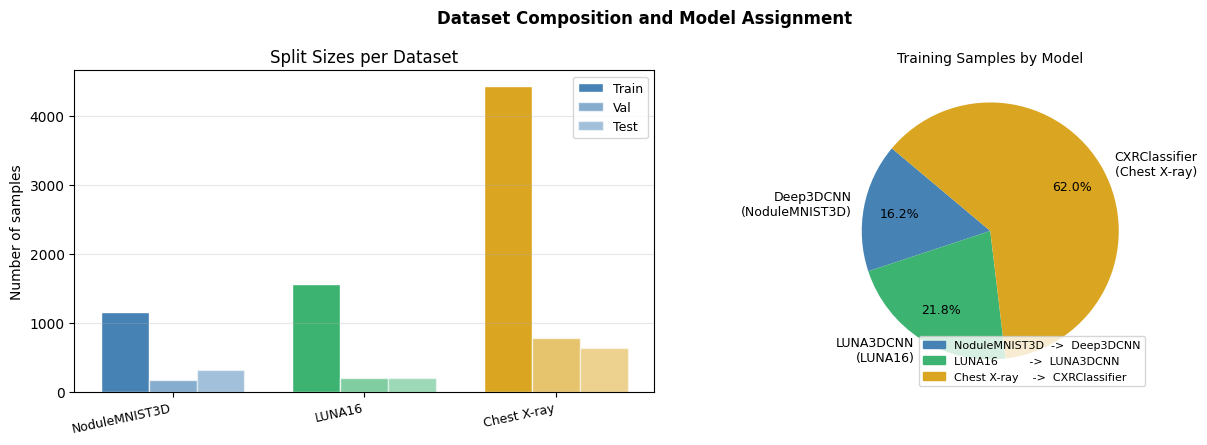

Deep3DCNN    : train=1,158  val=165  test=310
LUNA3DCNN    : train=1,560  val=195  test=195
CXRClassifier: train=4,433  val=783  test=624
CXR class balance: Cancer=3293 (74.3%)  NORMAL=1140 (25.7%)


In [124]:
import matplotlib.patches as mpatches

datasets_info = {
    "NoduleMNIST3D": {"train": len(train_ds),    "val": len(val_ds),    "test": len(test_ds),    "key": "nodule"},
    "LUNA16":        {"train": len(luna16_train), "val": len(luna16_val),"test": len(luna16_test),"key": "luna16"},
    "Chest X-ray":   {"train": len(cxr_train),    "val": len(cxr_val),  "test": len(cxr_test),   "key": "cxr"},
}
COLORS = {"nodule": "steelblue", "luna16": "mediumseagreen", "cxr": "goldenrod"}

ds_names = list(datasets_info.keys())
x = np.arange(len(ds_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Dataset Composition and Model Assignment", fontsize=12, fontweight="bold")

for split, offset, alpha in [("train", -width, 1.0), ("val", 0, 0.65), ("test", width, 0.5)]:
    vals   = [datasets_info[n][split] for n in ds_names]
    colors = [COLORS[datasets_info[n]["key"]] for n in ds_names]
    axes[0].bar(x + offset, vals, width, label=split.capitalize(), color=colors, alpha=alpha, edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(ds_names, rotation=12, ha="right", fontsize=9)
axes[0].set_ylabel("Number of samples"); axes[0].set_title("Split Sizes per Dataset")
axes[0].legend(fontsize=9); axes[0].grid(axis="y", alpha=0.3)

model_sizes = {
    "Deep3DCNN\n(NoduleMNIST3D)": len(deep_train_ds),
    "LUNA3DCNN\n(LUNA16)":        len(luna_train_ds),
    "CXRClassifier\n(Chest X-ray)": len(cxr_train),
}
axes[1].pie(model_sizes.values(), labels=model_sizes.keys(),
            colors=["steelblue", "mediumseagreen", "goldenrod"], autopct="%1.1f%%",
            startangle=140, textprops={"fontsize": 9}, pctdistance=0.72)
patches = [
    mpatches.Patch(color="steelblue",      label="NoduleMNIST3D  ->  Deep3DCNN"),
    mpatches.Patch(color="mediumseagreen", label="LUNA16         ->  LUNA3DCNN"),
    mpatches.Patch(color="goldenrod",      label="Chest X-ray    ->  CXRClassifier"),
]
axes[1].legend(handles=patches, loc="lower right", fontsize=8)
axes[1].set_title("Training Samples by Model", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dataset_composition_{RUN_ID}.png"), dpi=200)
plt.show()

print(f"Deep3DCNN    : train={len(deep_train_ds):,}  val={len(deep_val_ds):,}  test={len(test_ds):,}")
print(f"LUNA3DCNN    : train={len(luna_train_ds):,}  val={len(luna_val_ds):,}  test={len(luna16_test):,}")
print(f"CXRClassifier: train={len(cxr_train):,}  val={len(cxr_val):,}  test={len(cxr_test):,}")
print(f"CXR class balance: Cancer={n_cxr_pos} ({100*n_cxr_pos/len(cxr_train):.1f}%)  "
      f"NORMAL={n_cxr_neg} ({100*n_cxr_neg/len(cxr_train):.1f}%)")


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## Handle class imbalance helper
### Using `pos_weight`

In [125]:
def get_label_array(ds):
    return np.array([int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))], dtype=int)

# Deep3DCNN pos_weight (NoduleMNIST3D)
y_deep = get_label_array(deep_train_ds)
n_pos_d, n_neg_d = int((y_deep == 1).sum()), int((y_deep == 0).sum())
deep_pos_weight   = torch.tensor([n_neg_d / max(n_pos_d, 1)], dtype=torch.float32, device=device)
print(f"Deep3DCNN   pos_weight={deep_pos_weight.item():.3f}  "
      f"(pos={n_pos_d} = {n_pos_d/(n_pos_d+n_neg_d)*100:.1f}%  neg={n_neg_d})")

# WeightedRandomSampler: boost malignant to 40% per batch (natural ~25%).
TARGET_MAL_RATE = 0.40
deep_sample_weights = torch.tensor(
    [TARGET_MAL_RATE / n_pos_d if lbl == 1 else (1 - TARGET_MAL_RATE) / n_neg_d
     for lbl in y_deep], dtype=torch.float)
print(f"  WeightedRandomSampler: targeting {TARGET_MAL_RATE*100:.0f}% malignant per batch")

# LUNA3DCNN pos_weight (LUNA16)
y_luna = get_label_array(luna_train_ds)
n_pos_l, n_neg_l = int((y_luna == 1).sum()), int((y_luna == 0).sum())
luna_pos_weight   = torch.tensor([n_neg_l / max(n_pos_l, 1)], dtype=torch.float32, device=device)
print(f"LUNA3DCNN   pos_weight={luna_pos_weight.item():.3f}  (pos={n_pos_l}  neg={n_neg_l})")

# CXRClassifier pos_weight (natural training distribution)
n_pos_s = sum(1 for _, lbl in cxr_train.samples if lbl == 1)
n_neg_s = sum(1 for _, lbl in cxr_train.samples if lbl == 0)
small_pos_weight = torch.tensor([n_neg_s / max(n_pos_s, 1)], dtype=torch.float32, device=device)
print(f"CXRClassifier pos_weight={small_pos_weight.item():.3f}  (pos={n_pos_s}  neg={n_neg_s})")
print(f"  natural train rate: {n_pos_s/(n_pos_s+n_neg_s)*100:.1f}% Cancer (no sampler)")


Deep3DCNN   pos_weight=2.925  (pos=295 = 25.5%  neg=863)
  WeightedRandomSampler: targeting 40% malignant per batch
LUNA3DCNN   pos_weight=2.171  (pos=492  neg=1068)
CXRClassifier pos_weight=0.346  (pos=3293  neg=1140)
  natural train rate: 74.3% Cancer (no sampler)


## DataLoader

In [126]:
def collate_fn(batch, train=False):
    xs, ys = zip(*batch)
    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()
    if x.ndim == 4:
        x = x.unsqueeze(1)
    eps = 1e-6
    mean = x.mean(dim=(2,3,4), keepdim=True)
    std  = x.std(dim=(2,3,4), keepdim=True)
    x    = (x - mean) / (std + eps)
    if x.shape[-1] != PATCH_SIZE:
        x = F.interpolate(x, size=(PATCH_SIZE,)*3, mode="trilinear", align_corners=False)
    if train:
        for dim in [2, 3, 4]:
            if torch.rand(1).item() < 0.5: x = torch.flip(x, dims=[dim])
        # Random 90-degree rotation on any axis pair
        if torch.rand(1).item() < 0.5:
            k = torch.randint(1, 4, (1,)).item()
            ax_pair = [(2,3),(2,4),(3,4)][torch.randint(0,3,(1,)).item()]
            x = torch.rot90(x, k=k, dims=list(ax_pair))
        if torch.rand(1).item() < 0.3:
            D = x.shape[2]; scale = 1.0 + 0.15 * torch.rand(1).item()
            new_D = max(int(D * scale), D + 1)
            xz = F.interpolate(x, size=(new_D,)*3, mode="trilinear", align_corners=False)
            s  = (new_D - D) // 2
            x  = xz[:,:,s:s+D,s:s+D,s:s+D]
        if torch.rand(1).item() < 0.4: x = x * (0.85 + 0.3 * torch.rand(1).item())
        if torch.rand(1).item() < 0.4: x = x + 0.05 * torch.randn_like(x)
        if torch.rand(1).item() < 0.2:
            D = x.shape[2]; csize = 8
            d0 = torch.randint(0, max(1, D-csize), (1,)).item()
            h0 = torch.randint(0, max(1, D-csize), (1,)).item()
            w0 = torch.randint(0, max(1, D-csize), (1,)).item()
            x[:,:,d0:d0+csize,h0:h0+csize,w0:w0+csize] = 0.0
    return x, y

def cxr_collate_fn(batch):
    xs, ys = zip(*batch)
    x = torch.stack(xs)
    y = torch.tensor([int(np.array(yi).reshape(-1)[0]) for yi in ys]).long()
    return x, y

_kw = dict(num_workers=cfg.num_workers, pin_memory=False)
_col_train = lambda b: collate_fn(b, train=True)
_col_eval  = lambda b: collate_fn(b, train=False)

# Model 1: Deep3DCNN — WeightedRandomSampler oversamples malignant class to 40% per batch
deep_sampler = WeightedRandomSampler(
    deep_sample_weights, num_samples=len(deep_train_ds), replacement=True
)
deep_train_loader = DataLoader(deep_train_ds, batch_size=cfg.batch_size,
                               sampler=deep_sampler, collate_fn=_col_train, **_kw)
deep_val_loader   = DataLoader(deep_val_ds, batch_size=cfg.batch_size,
                               shuffle=False, collate_fn=_col_eval, **_kw)

# Model 2: LUNA3DCNN (LUNA16)
luna_train_loader = DataLoader(luna_train_ds, batch_size=cfg.batch_size,
                               shuffle=True, collate_fn=_col_train, **_kw)
luna_val_loader   = DataLoader(luna_val_ds, batch_size=cfg.batch_size,
                               shuffle=False, collate_fn=_col_eval, **_kw)

# Model 3: CXRClassifier
small_train_loader = DataLoader(cxr_train, batch_size=32, shuffle=True,
                                collate_fn=cxr_collate_fn, **_kw)
small_val_loader   = DataLoader(cxr_val, batch_size=32, shuffle=False,
                                collate_fn=cxr_collate_fn, **_kw)

# Test loaders
test_loader        = DataLoader(test_ds, batch_size=cfg.batch_size,
                                shuffle=False, collate_fn=_col_eval, **_kw)
luna16_test_loader = DataLoader(luna16_test, batch_size=cfg.batch_size,
                                shuffle=False, collate_fn=_col_eval, **_kw)
cxr_test_loader    = DataLoader(cxr_test, batch_size=32, shuffle=False,
                                collate_fn=cxr_collate_fn, **_kw)

print("Deep3DCNN     - train:", len(deep_train_loader), "batches  |  val:", len(deep_val_loader))
print("LUNA3DCNN     - train:", len(luna_train_loader), "batches  |  val:", len(luna_val_loader))
print("CXRClassifier - train:", len(small_train_loader), "batches  |  val:", len(small_val_loader))


Deep3DCNN     - train: 10 batches  |  val: 2
LUNA3DCNN     - train: 13 batches  |  val: 2
CXRClassifier - train: 139 batches  |  val: 25


## Data Visualization

x0 shape: (1, 28, 28, 28)   dtype: float64   min: 0.0   max: 1.0   label: [0]


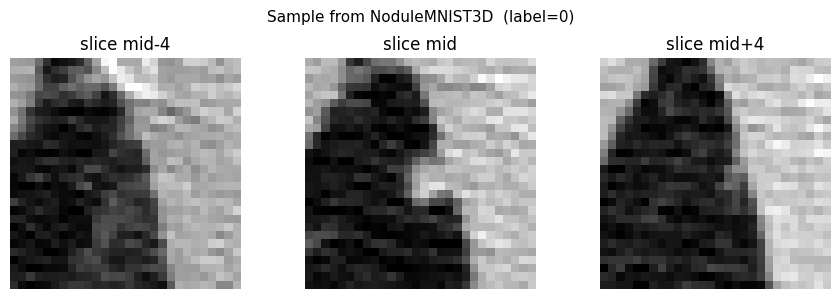

batch shapes: torch.Size([128, 1, 32, 32, 32]) torch.Size([128, 1])


In [127]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "  dtype:", x0.dtype,
      "  min:", x0.min(), "  max:", x0.max(), "  label:", y0)

vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Auto-scale each slice so we can see the content regardless of intensity range
def _auto(sl):
    lo, hi = sl.min(), sl.max()
    return (sl - lo) / (hi - lo + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.suptitle(f"Sample from NoduleMNIST3D  (label={int(np.array(y0).ravel()[0])})", fontsize=11)
axes[0].imshow(_auto(vol[mid-4]), cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(_auto(vol[mid]),   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(_auto(vol[mid+4]), cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

xb, yb = next(iter(deep_train_loader))
print("batch shapes:", xb.shape, yb.shape)


## Case Examples: Benign vs Malignant

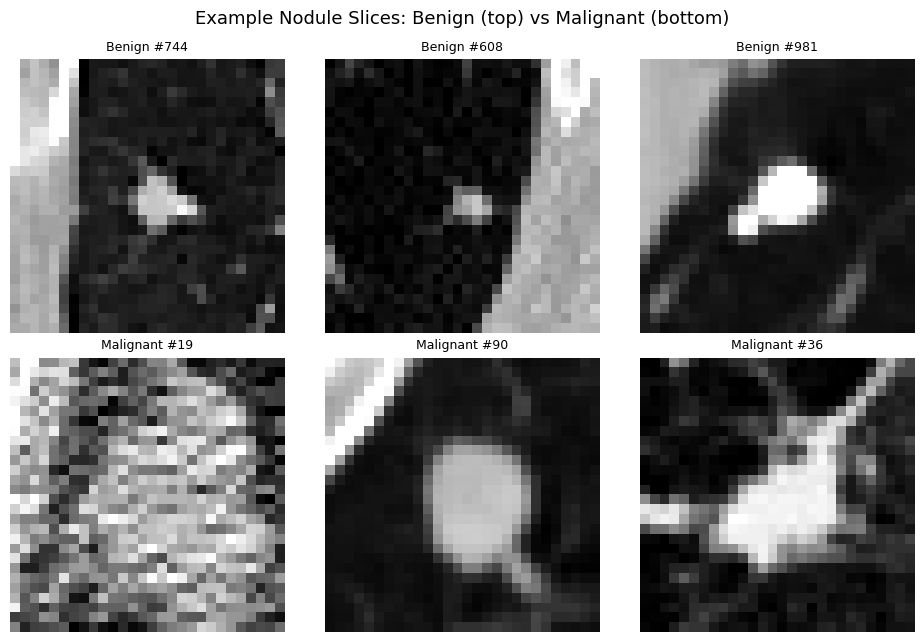

In [128]:
# Representative slices for each class

def show_class_examples(ds, n_per_class=3, seed=0):
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    benign_idx    = np.where(y_all == 0)[0]
    malignant_idx = np.where(y_all == 1)[0]

    chosen_b = rng.choice(benign_idx,    size=n_per_class, replace=False)
    chosen_m = rng.choice(malignant_idx, size=n_per_class, replace=False)

    fig, axes = plt.subplots(
        2, n_per_class, figsize=(n_per_class * 3.2, 6.5)
    )
    fig.suptitle("Example Nodule Slices: Benign (top) vs Malignant (bottom)", fontsize=13)

    for col, idx in enumerate(chosen_b):
        vol = np.array(ds[idx][0])            # (1, 28, 28, 28) or (28,28,28)
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[0, col].imshow(vol[mid], cmap="gray")
        axes[0, col].set_title(f"Benign #{idx}", fontsize=9)
        axes[0, col].axis("off")

    for col, idx in enumerate(chosen_m):
        vol = np.array(ds[idx][0])
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[1, col].imshow(vol[mid], cmap="gray")
        axes[1, col].set_title(f"Malignant #{idx}", fontsize=9)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"case_examples_{RUN_ID}.png"), dpi=200)
    plt.show()

show_class_examples(train_ds, n_per_class=3)

## 3D Surface Visualization

Using marching cubes to render the nodule as a 3D mesh surface, adapted from Guido Zuidhof's DICOM preprocessing notebook. The threshold controls which voxel intensity is treated as the nodule boundary.

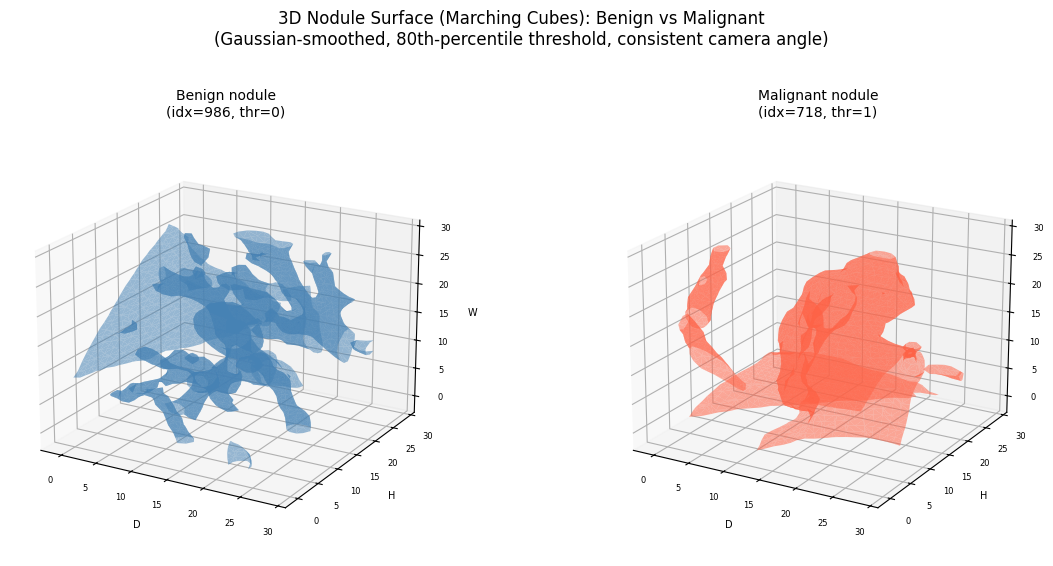

In [129]:
# 3D surface visualization using marching cubes.
# Gaussian smoothing applied before marching cubes reduces the voxel-level
# staircase noise that produces the "blob" appearance.
# A tighter percentile threshold (80th) captures only the core nodule tissue.

import scipy.ndimage as nd_img

def plot_3d_nodule(vol, threshold=None, color="steelblue", title="", ax=None):
    """
    Render a 28×28×28 nodule volume as a 3D isosurface (marching cubes).

    vol       : (1,D,H,W) or (D,H,W) uint8/float array
    threshold : HU/intensity level.  None → 80th percentile of the smoothed vol.
    """
    if vol.ndim == 4:
        vol = vol[0]
    vol_f = vol.astype(np.float32)

    # Gaussian smooth to suppress voxel-level noise before surface extraction
    vol_s = nd_img.gaussian_filter(vol_f, sigma=0.8)

    if threshold is None:
        threshold = float(np.percentile(vol_s, 80))

    try:
        verts, faces, _, _ = measure.marching_cubes(vol_s, level=threshold)
    except (ValueError, RuntimeError):
        print(f"  No surface at thr={threshold:.1f} for \"{title}\"")
        return

    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(5, 5))
        ax  = fig.add_subplot(111, projection='3d')

    mesh = Poly3DCollection(verts[faces], alpha=0.55, linewidth=0)
    mesh.set_facecolor(color)
    mesh.set_edgecolor("none")
    ax.add_collection3d(mesh)

    D, H, W = vol_f.shape
    # Add generous padding so the surface sits inside the axes
    PAD = 3
    ax.set_xlim(-PAD, D + PAD)
    ax.set_ylim(-PAD, H + PAD)
    ax.set_zlim(-PAD, W + PAD)

    ax.set_title(title or f"3D surface (thr={threshold:.0f})", fontsize=10, pad=6)
    ax.set_xlabel("D", fontsize=7); ax.set_ylabel("H", fontsize=7); ax.set_zlabel("W", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=20, azim=-60)   # consistent camera angle

    if standalone:
        plt.tight_layout()
        plt.show()


def show_3d_class_examples(ds, seed=0):
    """Side-by-side 3D surface renders for one benign and one malignant nodule."""
    rng   = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    idx_b = int(rng.choice(np.where(y_all == 0)[0]))
    idx_m = int(rng.choice(np.where(y_all == 1)[0]))

    fig = plt.figure(figsize=(12, 5.5))
    fig.suptitle(
        "3D Nodule Surface (Marching Cubes): Benign vs Malignant\n"
        "(Gaussian-smoothed, 80th-percentile threshold, consistent camera angle)",
        fontsize=12, y=1.02
    )

    for col, (label_name, idx, color) in enumerate(
        [("Benign", idx_b, "steelblue"), ("Malignant", idx_m, "tomato")]
    ):
        ax  = fig.add_subplot(1, 2, col + 1, projection='3d')
        vol = np.array(ds[idx][0])
        thr = float(np.percentile(nd_img.gaussian_filter(
            vol.squeeze().astype(np.float32), sigma=0.8), 80))
        plot_3d_nodule(vol, threshold=thr, color=color,
                       title=f"{label_name} nodule\n(idx={idx}, thr={thr:.0f})", ax=ax)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"3d_surface_{RUN_ID}.png"), dpi=200, bbox_inches="tight")
    plt.show()


show_3d_class_examples(train_ds)


## Full 3D Lung CT Reconstruction

Renders a complete LUNA16 CT scan as a 3D isosurface mesh using marching cubes.
Two thresholds are shown:
- **−300 HU** (navy): captures lung walls, soft tissue, vessels, and bone, similar to the standard 3D reconstructions used in radiological workstations
- **+200 HU** (sienna): captures dense structures only (bone and calcified tissue)

The scan is downsampled before rendering to keep memory usage reasonable. Annotated nodule positions are overlaid as scatter points.

Rendering : 1.3.6.1.4.1.14519.5.2.1.6279.6001.10062138301623374678017074...
Nodules   : 4
Scan shape : (321, 512, 512)  (Z×Y×X)
HU range   : -1000 – 3000
Spacing    : 0.56×0.56×1.00 mm/vox
Downsampled: (112, 179, 179)


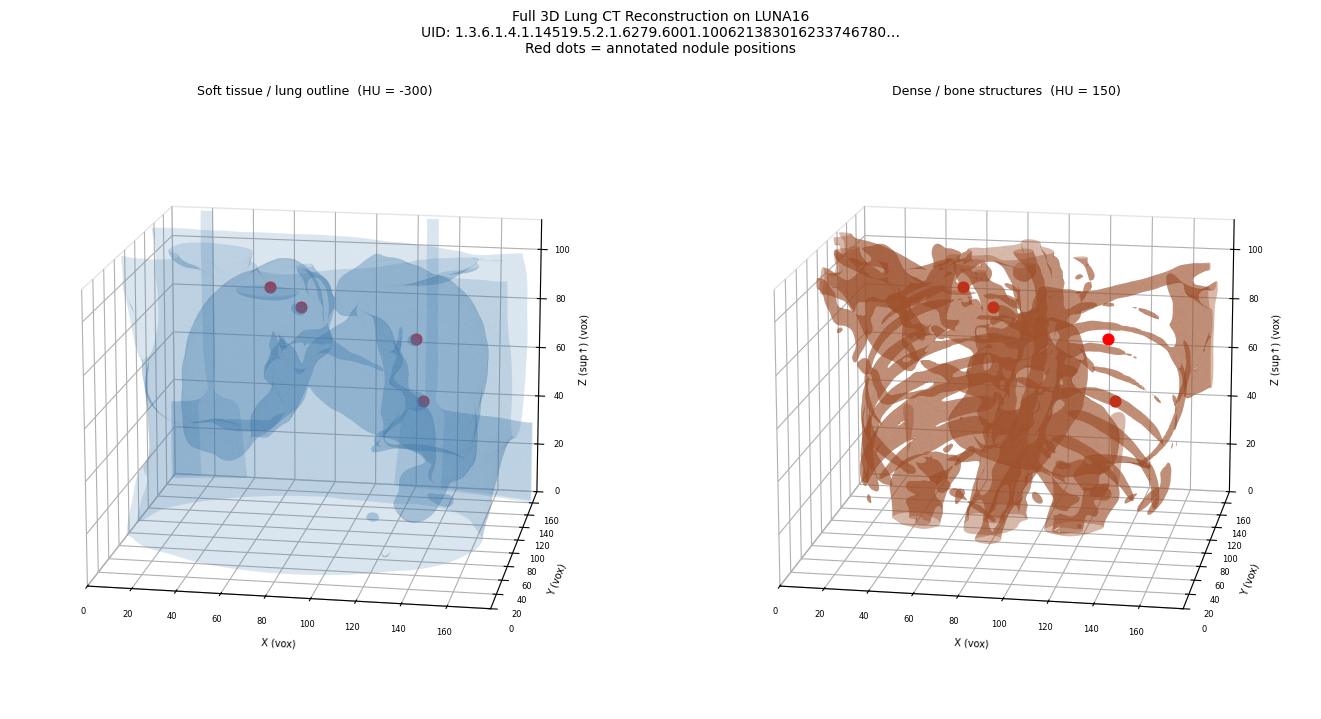

In [130]:
import SimpleITK as sitk
import scipy.ndimage as nd_img
import pandas as pd
from pathlib import Path

LUNA16_ROOT = Path(os.path.join(REPO_ROOT, "data", "Luna16"))
ann_df = pd.read_csv(LUNA16_ROOT / "annotations.csv")

def render_full_lung(mhd_path: str, nodule_coords=None, downsample_factor=0.35,
                     threshold_soft=-300.0, threshold_bone=150.0):
    """
    Load a full LUNA16 CT scan and render it as two 3D isosurface meshes.

    - threshold_soft (-300 HU): captures lung walls, airways, vessels, and soft tissue
    - threshold_bone (+200 HU): captures dense/bone structures (ribs, spine)
    Nodule world-coordinate annotations are overlaid as red scatter points.
    """
    img    = sitk.ReadImage(mhd_path)
    hu_arr = sitk.GetArrayFromImage(img).astype(np.float32)  # (Z, Y, X) in HU
    origin  = np.array(img.GetOrigin())    # (X, Y, Z) mm
    spacing = np.array(img.GetSpacing())   # (X, Y, Z) mm/voxel

    print(f"Scan shape : {hu_arr.shape}  (Z×Y×X)")
    print(f"HU range   : {hu_arr.min():.0f} – {hu_arr.max():.0f}")
    print(f"Spacing    : {spacing[0]:.2f}×{spacing[1]:.2f}×{spacing[2]:.2f} mm/vox")

    # Downsample for rendering speed
    arr_ds = nd_img.zoom(hu_arr, [downsample_factor]*3, order=1)
    print(f"Downsampled: {arr_ds.shape}")

    # Correct orientation
    # SimpleITK loads LUNA16 as (Z, Y, X) where Z goes from inferior to superior.
    # Transposing to (X, Y, Z) puts the patient upright in the matplotlib 3D axes
    # (z-axis = superior direction = "up").
    arr_plot = arr_ds.transpose(2, 1, 0)   # now (X, Y, Z)
    Nx, Ny, Nz = arr_plot.shape

    def mc(arr, level):
        try:
            v, f, _, _ = measure.marching_cubes(arr, level=level)
            return v, f
        except (ValueError, RuntimeError):
            return None, None

    # Gaussian smoothing before marching cubes removes voxel-level
    # staircasing noise that makes the surface look rough/spiky.
    arr_smooth = nd_img.gaussian_filter(arr_plot, sigma=2.0)
    verts_s, faces_s = mc(arr_smooth, threshold_soft)
    verts_b, faces_b = mc(arr_smooth, threshold_bone)

    # Convert nodule world-coords → downsampled plot voxel coords
    nodule_plot_coords = []
    if nodule_coords:
        for cx_mm, cy_mm, cz_mm in nodule_coords:
            xi = ((cx_mm - origin[0]) / spacing[0]) * downsample_factor
            yi = ((cy_mm - origin[1]) / spacing[1]) * downsample_factor
            zi = ((cz_mm - origin[2]) / spacing[2]) * downsample_factor
            # After transpose(2,1,0): new axes are xi→x, yi→y, zi→z
            nodule_plot_coords.append((xi, yi, zi))

    # Render
    fig = plt.figure(figsize=(14, 7))   # light / white background
    fig.patch.set_facecolor("white")

    panel_configs = [
        (verts_s, faces_s, "steelblue", 0.20,
         f"Soft tissue / lung outline  (HU = {threshold_soft:.0f})"),
        (verts_b, faces_b, "sienna",    0.45,
         f"Dense / bone structures  (HU = {threshold_bone:.0f})"),
    ]

    for col, (verts, faces, color, alpha, label) in enumerate(panel_configs):
        ax = fig.add_subplot(1, 2, col + 1, projection="3d")
        ax.set_facecolor("white")

        if verts is not None:
            mesh = Poly3DCollection(verts[faces], alpha=alpha, linewidth=0)
            mesh.set_facecolor(color)
            mesh.set_edgecolor("none")
            ax.add_collection3d(mesh)

        ax.set_xlim(0, Nx); ax.set_ylim(0, Ny); ax.set_zlim(0, Nz)
        ax.view_init(elev=15, azim=-80)      # patient upright, slightly front-facing

        # Overlay nodule positions
        for xi, yi, zi in nodule_plot_coords:
            ax.scatter([xi], [yi], [zi], c="red", s=60, zorder=10,
                       depthshade=False, label="annotated nodule")

        ax.set_title(label, fontsize=9, color="black", pad=4)
        ax.set_xlabel("X (vox)", fontsize=7)
        ax.set_ylabel("Y (vox)", fontsize=7)
        ax.set_zlabel("Z (sup↑) (vox)", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor("#cccccc")
        ax.yaxis.pane.set_edgecolor("#cccccc")
        ax.zaxis.pane.set_edgecolor("#cccccc")
        ax.grid(True, alpha=0.2)

    uid = Path(mhd_path).stem
    plt.suptitle(
        f"Full 3D Lung CT Reconstruction on LUNA16\nUID: {uid[:55]}…\n"
        f"Red dots = annotated nodule positions",
        fontsize=10, color="black", y=1.02
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"full_lung_3d_{RUN_ID}.png"),
                dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


# Pick a scan with ≥2 annotated nodules
uid_to_mhd = {p.stem: str(p)
               for p in sorted(LUNA16_ROOT.glob("subset*/subset*/*.mhd"))}

ann_filt = ann_df[ann_df.seriesuid.isin(uid_to_mhd)]
counts   = ann_filt.groupby("seriesuid").size()
chosen_uid = counts[counts >= 2].index[0]
chosen_mhd = uid_to_mhd[chosen_uid]

nodule_xyz = list(ann_filt[ann_filt.seriesuid == chosen_uid]
                  [["coordX","coordY","coordZ"]].itertuples(index=False, name=None))

print(f"Rendering : {chosen_uid[:60]}...")
print(f"Nodules   : {len(nodule_xyz)}")
render_full_lung(chosen_mhd, nodule_coords=nodule_xyz)


## Multi-View Slice Comparison (Axial / Sagittal / Coronal)

Displays the three orthogonal mid-plane cuts, the same views radiologists use when reading a CT scan.

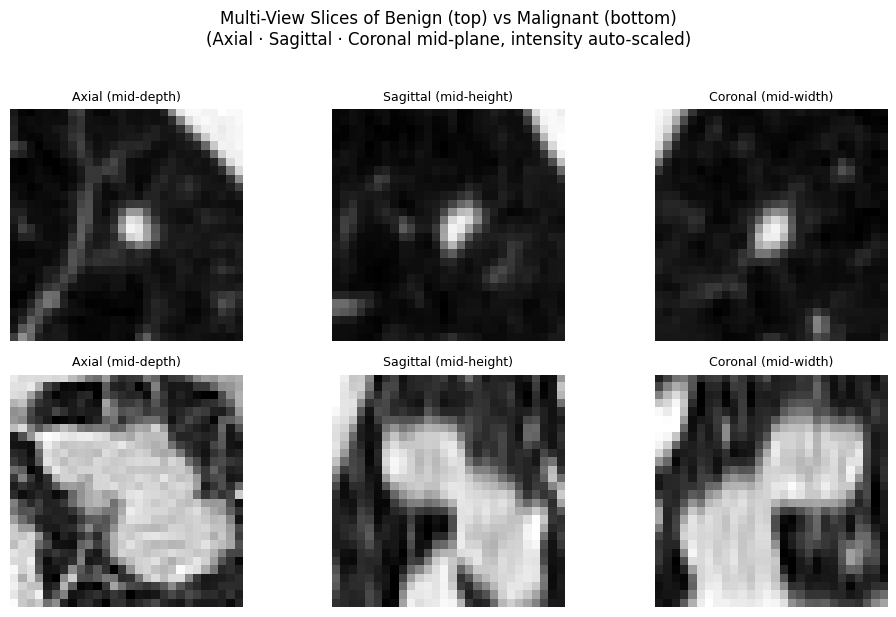

In [131]:
# Multi-view visualization: axial, sagittal, and coronal mid-plane slices
# Mirrors the standard radiology reading planes used in clinical CT review.

def show_multiview(vol, title="", cmap="gray", ax_row=None):
    """
    Display axial (D), sagittal (H), and coronal (W) mid-plane slices.
    vol: (1, D, H, W) or (D, H, W) uint8/float array.
    Auto-scales intensity so the image is never black regardless of data range.
    """
    if vol.ndim == 4:
        vol = vol[0]
    d, h, w = vol.shape

    vol_f = vol.astype(np.float32)
    # Clip to [1st, 99th] percentile and rescale to [0, 1] — prevents
    # all-black images when the raw intensity range is very small.
    lo, hi = np.percentile(vol_f, 1), np.percentile(vol_f, 99)
    if hi > lo:
        vol_f = np.clip(vol_f, lo, hi)
        vol_f = (vol_f - lo) / (hi - lo)
    else:
        vol_f = np.zeros_like(vol_f)

    slices = [
        vol_f[d // 2, :, :],
        vol_f[:, h // 2, :],
        vol_f[:, :, w // 2],
    ]
    slice_labels = ["Axial (mid-depth)", "Sagittal (mid-height)", "Coronal (mid-width)"]

    if ax_row is None:
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        standalone = True
    else:
        axes = ax_row
        standalone = False

    for ax, sl, st in zip(axes, slices, slice_labels):
        ax.imshow(sl, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(st, fontsize=9)
        ax.axis("off")

    if standalone:
        fig.suptitle(title, fontsize=11)
        plt.tight_layout()
        plt.show()


def show_multiview_class_comparison(ds, seed=0):
    """Show axial/sagittal/coronal views for one benign and one malignant sample."""
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    idx_b = int(rng.choice(np.where(y_all == 0)[0]))
    idx_m = int(rng.choice(np.where(y_all == 1)[0]))

    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    fig.suptitle(
        "Multi-View Slices of Benign (top) vs Malignant (bottom)\n"
        "(Axial · Sagittal · Coronal mid-plane, intensity auto-scaled)",
        fontsize=12, y=1.02
    )

    show_multiview(np.array(ds[idx_b][0]), ax_row=axes[0])
    show_multiview(np.array(ds[idx_m][0]), ax_row=axes[1])

    axes[0][0].set_ylabel("Benign", fontsize=10, labelpad=8)
    axes[1][0].set_ylabel("Malignant", fontsize=10, labelpad=8)

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"multiview_comparison_{RUN_ID}.png"), dpi=200)
    plt.show()


show_multiview_class_comparison(train_ds)


## Model 1: Deep3DCNN (NoduleMNIST3D)

**Two-phase training strategy:**

**Phase 1 — LUNA16 pretraining (20 epochs):**
The backbone is first trained on LUNA16 (nodule vs. background) to initialise the weights
with meaningful 3D CT feature representations. LUNA16 is visually simpler — a dense
spherical structure against uniform lung parenchyma — so the model quickly develops
3D edge detectors, density gradient features, and spherical shape encodings.
These low-level volumetric representations transfer directly to the harder malignancy task.

**Phase 2 — NoduleMNIST3D fine-tuning (up to 60 epochs, patience=10):**
The pretrained backbone is fine-tuned on NoduleMNIST3D at a lower learning rate (1e-4).
A WeightedRandomSampler boosts malignant cases to 40% per batch (natural rate ~25%),
providing stronger gradient signal from the minority class throughout training.

**Architecture:** Deep3DCNN with Squeeze-and-Excitation channel attention. ~3.7 M params.


In [132]:
deep_model = Deep3DCNN(dropout_p=0.5).to(device)

# Label-smoothed BCE with pos_weight.
# pos_weight handles the class imbalance; WeightedRandomSampler provides additional
# gradient amplification on the malignant minority class.
LABEL_SMOOTHING = 0.05
WARMUP_EPOCHS   = 5

def smooth_bce(logits, y, pos_weight, eps=LABEL_SMOOTHING):
    y_s = y.float() * (1 - eps) + eps / 2
    return F.binary_cross_entropy_with_logits(logits, y_s,
                                               pos_weight=pos_weight, reduction="mean")

# Separate criteria for each phase: LUNA16 uses luna_pos_weight; NoduleMNIST3D uses deep_pos_weight
deep_criterion_luna = lambda logits, y: smooth_bce(logits, y, luna_pos_weight)
deep_criterion_nod  = lambda logits, y: smooth_bce(logits, y, deep_pos_weight)

# Phase 1 optimizer: higher LR to learn from scratch on LUNA16
deep_optimizer_p1 = torch.optim.AdamW(deep_model.parameters(),
                                       lr=3e-4, weight_decay=1e-4)
deep_scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    deep_optimizer_p1, T_max=20, eta_min=1e-5)

# Phase 2 optimizer: lower LR for fine-tuning on NoduleMNIST3D
deep_optimizer_p2 = torch.optim.AdamW(deep_model.parameters(),
                                       lr=1e-4, weight_decay=1e-4)
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR as CosLR, SequentialLR
_warm = LinearLR(deep_optimizer_p2, start_factor=0.1, end_factor=1.0,
                 total_iters=WARMUP_EPOCHS)
_cos  = CosLR(deep_optimizer_p2, T_max=cfg.epochs - WARMUP_EPOCHS, eta_min=1e-6)
deep_scheduler_p2 = SequentialLR(deep_optimizer_p2,
                                   schedulers=[_warm, _cos], milestones=[WARMUP_EPOCHS])

n_deep = sum(p.numel() for p in deep_model.parameters())
print(f"Deep3DCNN  : {n_deep:,} params  (~{n_deep/1e6:.2f} M)  [SE attention]")
print(f"Phase 1: LUNA16 pretraining   LR=3e-4  cosine  20 epochs")
print(f"Phase 2: NoduleMNIST3D finetune  LR=1e-4  warmup+cosine  patience=10")
print(f"Loss: label-smoothed BCE  (eps={LABEL_SMOOTHING})  + WeightedRandomSampler (40% malignant)")


Deep3DCNN  : 7,070,497 params  (~7.07 M)  [SE attention]
Phase 1: LUNA16 pretraining   LR=3e-4  cosine  20 epochs
Phase 2: NoduleMNIST3D finetune  LR=1e-4  warmup+cosine  patience=10
Loss: label-smoothed BCE  (eps=0.05)  + WeightedRandomSampler (40% malignant)


## Training loop

In [133]:
from tqdm import tqdm

PHASE1_EPOCHS       = 20
EARLY_STOP_PATIENCE = 10

# Phase 1: LUNA16 pretraining
print("=" * 60)
print("Phase 1: LUNA16 pretraining  (Deep3DCNN, 20 epochs)")
print("=" * 60)

for epoch in range(1, PHASE1_EPOCHS + 1):
    deep_model.train()
    losses = []
    for x, y in tqdm(luna_train_loader, desc=f"p1 ep{epoch:02d}", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float().view(-1)
        deep_optimizer_p1.zero_grad(set_to_none=True)
        loss = deep_criterion_luna(deep_model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(deep_model.parameters(), max_norm=1.0)
        deep_optimizer_p1.step()
        losses.append(loss.item())
    deep_scheduler_p1.step()
    v_met = evaluate(deep_model, luna_val_loader, device, threshold=0.5)
    print(f"  ep {epoch:02d}/{PHASE1_EPOCHS} | train {np.mean(losses):.4f} | "
          f"LUNA16 val AUROC {v_met['auroc']:.4f} | "
          f"lr {deep_optimizer_p1.param_groups[0]['lr']:.2e}")

print(f"\nPhase 1 complete. Backbone pretrained on LUNA16.")

# Phase 2: NoduleMNIST3D fine-tuning
print("=" * 60)
print("Phase 2: NoduleMNIST3D fine-tuning  (Deep3DCNN, up to 60 epochs)")
print("=" * 60)

deep_history     = {"train_loss": [], "val_loss": [], "val": []}
deep_best_score  = -1.0
deep_best_epoch  = -1
patience_counter = 0

for epoch in range(1, cfg.epochs + 1):
    deep_model.train()
    losses = []
    for x, y in tqdm(deep_train_loader, desc=f"p2 ep{epoch:02d}", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float().view(-1)
        deep_optimizer_p2.zero_grad(set_to_none=True)
        loss = deep_criterion_nod(deep_model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(deep_model.parameters(), max_norm=1.0)
        deep_optimizer_p2.step()
        losses.append(loss.item())
    t_loss = float(np.mean(losses))

    v_loss = evaluate_loss(deep_model, deep_val_loader, deep_criterion_nod, device)
    v_met  = evaluate(deep_model, deep_val_loader, device,
                      threshold=cfg.threshold, criterion=deep_criterion_nod)
    v_met["val_loss"] = v_loss
    deep_scheduler_p2.step()

    auroc = f"{v_met['auroc']:.4f}" if v_met["auroc"] else "N/A"
    print(f"epoch {epoch:02d}/{cfg.epochs} | train {t_loss:.4f} | val {v_loss:.4f} | "
          f"auroc {auroc} | f1 {v_met['f1']:.4f} | "
          f"lr {deep_optimizer_p2.param_groups[0]['lr']:.2e}")

    deep_history["train_loss"].append(t_loss)
    deep_history["val_loss"].append(v_loss)
    deep_history["val"].append(v_met)

    score = v_met["auroc"] if v_met["auroc"] else v_met["f1"]
    if score > deep_best_score:
        deep_best_score = score; deep_best_epoch = epoch; patience_counter = 0
        save_checkpoint(os.path.join(RUN_DIR, "best_deep.pt"),
                        deep_model, deep_optimizer_p2, epoch,
                        {"val_metrics": v_met, "config": cfg.__dict__})
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

ckpt = torch.load(os.path.join(RUN_DIR, "best_deep.pt"), map_location=device)
deep_model.load_state_dict(ckpt["model_state"])
print(f"\nLoaded best Deep3DCNN from Phase 2 epoch {deep_best_epoch}")

save_json(metrics_path, {"deep_history": deep_history, "deep_best_epoch": deep_best_epoch})
print(f"Deep3DCNN done.  Phase 2 best epoch: {deep_best_epoch}  Val AUROC: {deep_best_score:.4f}")


Phase 1: LUNA16 pretraining  (Deep3DCNN, 20 epochs)


  ep 01/20 | train 1.0543 | LUNA16 val AUROC 0.6157 | lr 2.98e-04


  ep 02/20 | train 0.8977 | LUNA16 val AUROC 0.6423 | lr 2.93e-04


  ep 03/20 | train 0.8596 | LUNA16 val AUROC 0.6309 | lr 2.84e-04


  ep 04/20 | train 0.7432 | LUNA16 val AUROC 0.8285 | lr 2.72e-04


...

epoch 20/60 | train 0.6766 | val 0.7562 | auroc 0.8697 | f1 0.6481 | lr 8.29e-05


epoch 21/60 | train 0.7092 | val 0.6708 | auroc 0.8829 | f1 0.7000 | lr 8.07e-05


epoch 22/60 | train 0.6314 | val 0.7147 | auroc 0.8655 | f1 0.6735 | lr 7.84e-05


epoch 23/60 | train 0.6774 | val 0.7384 | auroc 0.8649 | f1 0.6214 | lr 7.61e-05


epoch 24/60 | train 0.6595 | val 0.7054 | auroc 0.8871 | f1 0.6476 | lr 7.36e-05
Early stopping at epoch 24

Loaded best Deep3DCNN from Phase 2 epoch 14
Deep3DCNN done.  Phase 2 best epoch: 14  Val AUROC: 0.8991


## Intermediate Feature Map Visualization

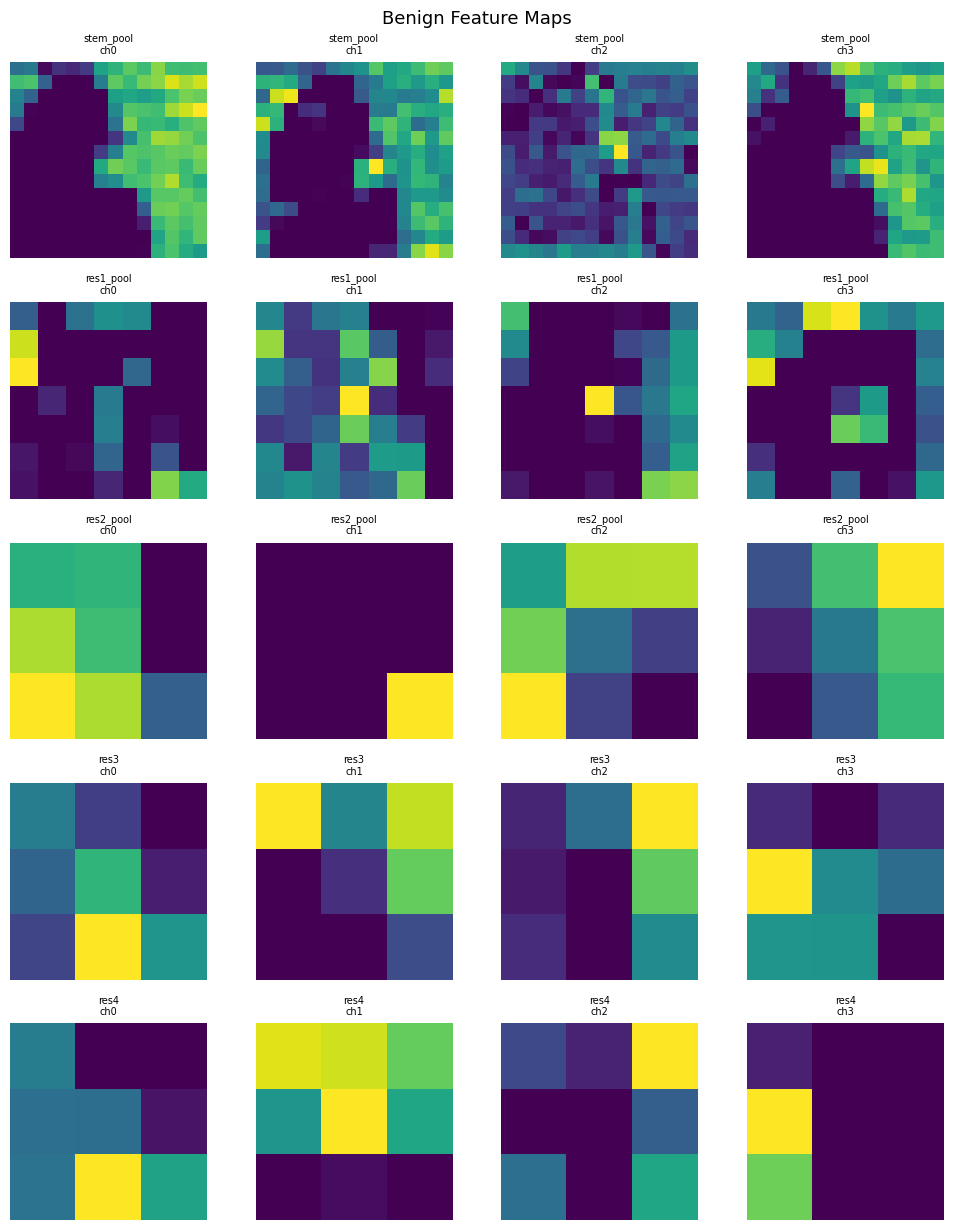

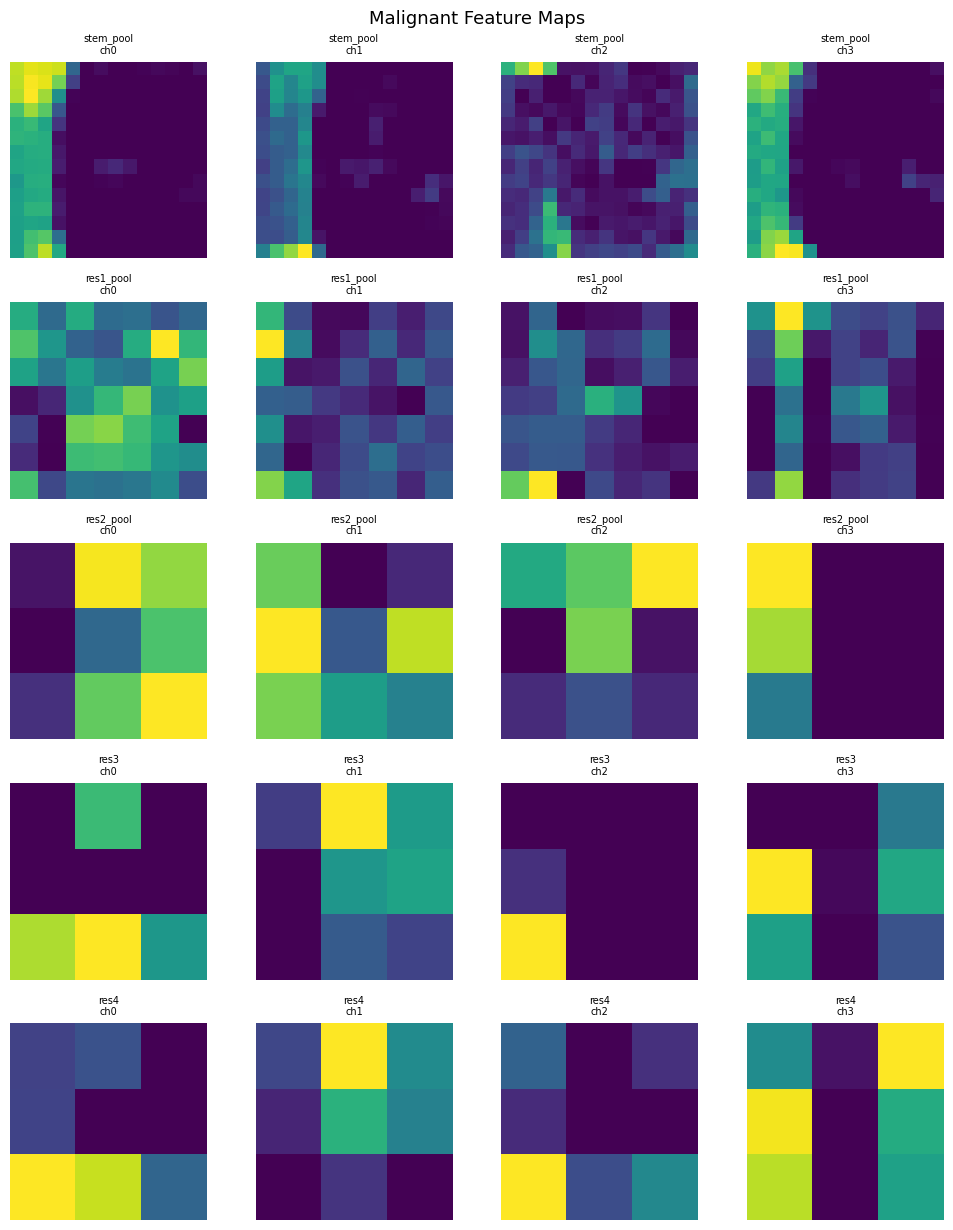

In [134]:
# Pick one benign and one malignant sample, run a forward pass,
# and display the first few channels of each residual stage.

def visualize_feature_maps(model, ds, device, n_channels=4):
    model.eval()
    y_all = get_label_array(ds)

    # pick first benign and first malignant
    idx_b = int(np.where(y_all == 0)[0][0])
    idx_m = int(np.where(y_all == 1)[0][0])

    for label_name, idx in [("Benign", idx_b), ("Malignant", idx_m)]:
        x_raw = np.array(ds[idx][0]).astype(np.float32)
        x_t   = torch.tensor(x_raw).unsqueeze(0)         # (1, 1, 28, 28, 28)
        if x_t.ndim == 4:
            x_t = x_t.unsqueeze(0)

        # Normalise the same way as collate_fn
        eps = 1e-6
        x_t = (x_t - x_t.mean()) / (x_t.std() + eps)
        x_t = x_t.to(device)

        with torch.no_grad():
            maps = model.get_feature_maps(x_t)

        stage_names = list(maps.keys())
        fig, axes = plt.subplots(
            len(stage_names), n_channels,
            figsize=(n_channels * 2.5, len(stage_names) * 2.5)
        )
        fig.suptitle(f"{label_name} Feature Maps", fontsize=13)

        for row, sname in enumerate(stage_names):
            fmap = maps[sname][0]        # (C, D, H, W) – drop batch dim
            mid_d = fmap.shape[1] // 2  # middle depth slice
            for col in range(n_channels):
                ax = axes[row, col] if len(stage_names) > 1 else axes[col]
                ch_map = fmap[col, mid_d].numpy()
                ax.imshow(ch_map, cmap="viridis")
                ax.set_title(f"{sname}\nch{col}", fontsize=7)
                ax.axis("off")

        plt.tight_layout()
        plt.savefig(
            os.path.join(FIG_DIR, f"feature_maps_{label_name.lower()}_{RUN_ID}.png"),
            dpi=200
        )
        plt.show()

visualize_feature_maps(deep_model, train_ds, device, n_channels=4)

## Threshold Tuning

The classification threshold is tuned on the NoduleMNIST3D validation set to
maximise F1 score, decoupling the operating point selection from the test set.
A threshold sweep over [0.05, 0.95] is run after training; the threshold with
highest validation F1 is selected and applied to the test set.


In [135]:
# Threshold tuning for Model 1 (Deep3DCNN)
# Tuned on NoduleMNIST3D val only so the operating point transfers to
# the NoduleMNIST3D test set (the primary cross-trial benchmark).

@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu().numpy())
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

y_val_nodule, logits_val_nodule = get_logits_and_labels(deep_model, nodule_val_loader, device)

thresholds = np.linspace(0.05, 0.95, 19)
best_deep_nodule = None
sweep_rows_nodule = []

for t in thresholds:
    met = compute_binary_metrics(y_val_nodule, logits_val_nodule, threshold=float(t))
    row = {"threshold": float(t), **{k: met[k] for k in
           ["f1","recall","precision","specificity","accuracy","auroc"]}}
    sweep_rows_nodule.append(row)
    if best_deep_nodule is None or row["f1"] > best_deep_nodule["f1"]:
        best_deep_nodule = row

deep_threshold = best_deep_nodule["threshold"]
print(f"Deep3DCNN NoduleMNIST3D val → best thr: {deep_threshold:.2f}  "
      f"(F1={best_deep_nodule['f1']:.3f}, "
      f"Recall={best_deep_nodule['recall']:.3f}, "
      f"Precision={best_deep_nodule['precision']:.3f})")


Deep3DCNN NoduleMNIST3D val → best thr: 0.85  (F1=0.732, Recall=0.714, Precision=0.750)


## Threshold Analysis & ROC Curve

Visualizes how each metric responds to threshold changes and the full ROC curve for the NoduleMNIST3D validation set.

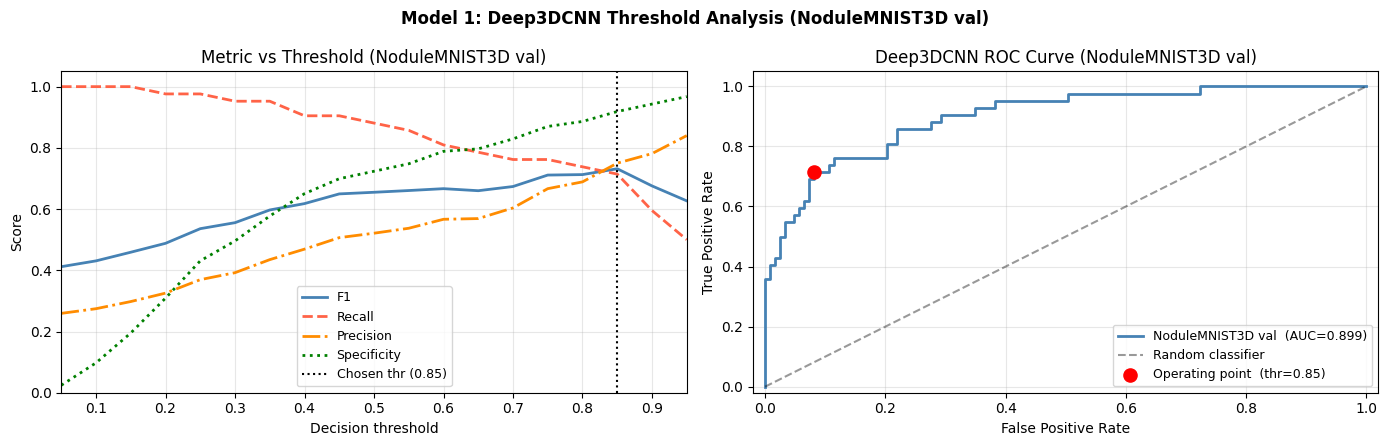

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Model 1: Deep3DCNN Threshold Analysis (NoduleMNIST3D val)",
             fontsize=12, fontweight="bold")

thr_vals = [r["threshold"] for r in sweep_rows_nodule]
for metric, color, ls in [
    ("f1",          "steelblue",  "-"),
    ("recall",      "tomato",     "--"),
    ("precision",   "darkorange", "-."),
    ("specificity", "green",      ":"),
]:
    axes[0].plot(thr_vals, [r[metric] for r in sweep_rows_nodule],
                 label=metric.capitalize(), color=color, linestyle=ls, linewidth=2)

axes[0].axvline(deep_threshold, color="black", linestyle=":", linewidth=1.5,
                label=f"Chosen thr ({deep_threshold:.2f})")
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Metric vs Threshold (NoduleMNIST3D val)")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_xlim(0.05, 0.95); axes[0].set_ylim(0, 1.05)

# ROC curve
probs_nodule = sigmoid(logits_val_nodule)
fpr, tpr, _ = sk_roc_curve(y_val_nodule, probs_nodule)
roc_auc = float(np.trapezoid(tpr, fpr))

axes[1].plot(fpr, tpr, color="steelblue", linewidth=2,
             label=f"NoduleMNIST3D val  (AUC={roc_auc:.3f})")
axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Random classifier")

probs_at_thr = (probs_nodule >= deep_threshold)
tpr_op = (probs_at_thr[y_val_nodule == 1]).mean()
fpr_op = (probs_at_thr[y_val_nodule == 0]).mean()
axes[1].scatter([fpr_op], [tpr_op], s=90, color="red", zorder=5,
                label=f"Operating point  (thr={deep_threshold:.2f})")

axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Deep3DCNN ROC Curve (NoduleMNIST3D val)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"deep_threshold_roc_{RUN_ID}.png"), dpi=200)
plt.show()


## Training Curves

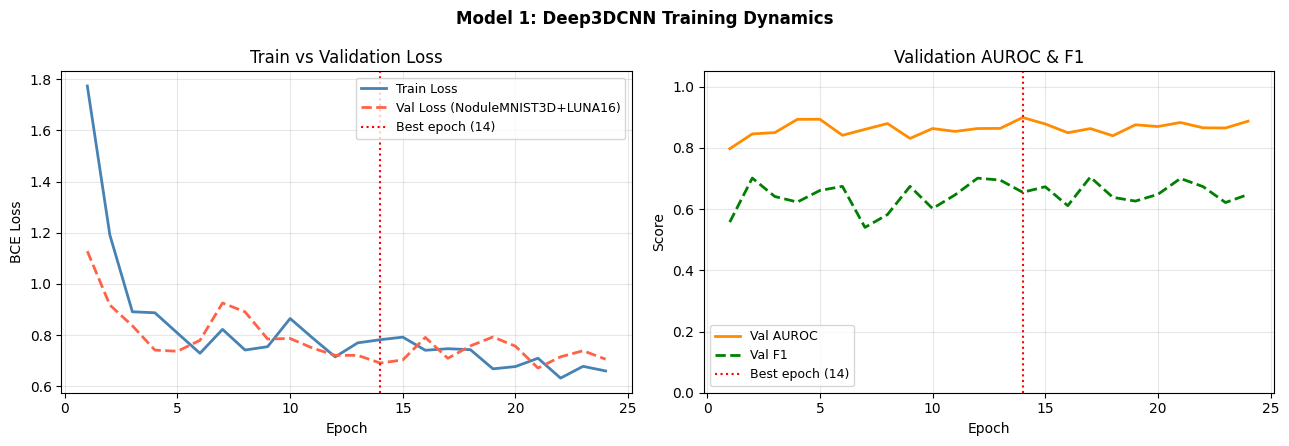

In [137]:
train_losses = deep_history["train_loss"]
val_losses   = deep_history["val_loss"]
val_aurocs   = [v["auroc"] for v in deep_history["val"]]
val_f1s      = [v["f1"]    for v in deep_history["val"]]
epochs_r     = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Model 1: Deep3DCNN Training Dynamics", fontsize=12, fontweight="bold")

axes[0].plot(epochs_r, train_losses, label="Train Loss", color="steelblue", linewidth=2)
axes[0].plot(epochs_r, val_losses,   label="Val Loss (NoduleMNIST3D+LUNA16)",
             color="tomato", linestyle="--", linewidth=2)
axes[0].axvline(deep_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({deep_best_epoch})")
axes[0].set_title("Train vs Validation Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_r, val_aurocs, label="Val AUROC", color="darkorange", linewidth=2)
axes[1].plot(epochs_r, val_f1s,   label="Val F1",    color="green", linestyle="--", linewidth=2)
axes[1].axvline(deep_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({deep_best_epoch})")
axes[1].set_title("Validation AUROC & F1"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score"); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"deep_train_curves_{RUN_ID}.png"), dpi=200)
plt.show()


## Test Evaluation

Each model is evaluated on its own held-out test split using the threshold
tuned on its corresponding validation set:
- **Deep3DCNN:** NoduleMNIST3D test split, threshold tuned on NoduleMNIST3D val
- **LUNA3DCNN:** LUNA16 test split, threshold tuned on LUNA16 val
- **CXRClassifier:** Chest X-ray test split, threshold tuned on CXR val

NoduleMNIST3D test AUROC is the primary benchmark for the Deep3DCNN model.


In [138]:
# Model 1: Deep3DCNN evaluated on NoduleMNIST3D only.
# LUNA16 is evaluated separately by LUNA3DCNN (Model 2).
nodule_test_deep = evaluate(deep_model, test_loader, device, threshold=deep_threshold)

print(f"Model 1 (Deep3DCNN) test results  [thr={deep_threshold:.2f}]")
print(f"  NoduleMNIST3D -- AUROC={nodule_test_deep['auroc']:.3f}  "
      f"F1={nodule_test_deep['f1']:.3f}  Recall={nodule_test_deep['recall']:.3f}  "
      f"Prec={nodule_test_deep['precision']:.3f}  Spec={nodule_test_deep['specificity']:.3f}  "
      f"Acc={nodule_test_deep['accuracy']:.3f}")

with open(metrics_path, "r") as f: m_all = json.load(f)
m_all["deep_threshold"]   = deep_threshold
m_all["test_nodule_deep"] = nodule_test_deep
with open(metrics_path, "w") as f: json.dump(m_all, f, indent=2)


Model 1 (Deep3DCNN) test results  [thr=0.85]
  NoduleMNIST3D -- AUROC=0.906  F1=0.700  Recall=0.766  Prec=0.645  Spec=0.890  Acc=0.865


---

## Model 3: CXRClassifier — ResNet-18 for Chest X-ray Cancer Screening

**Model:** ResNet-18 backbone (ImageNet pretrained), 1-channel first conv,
GAP -> Dropout(0.5) -> Linear(512->1). ~11.2 M parameters.

**Training:** Natural class distribution (no WeightedRandomSampler); differential
learning rates — backbone=1e-4, classification head=5e-4. Early stopping on val AUROC.

**Post-hoc calibration:** Temperature scaling optimised on the validation set.
The calibrated probabilities allow the threshold sweep to select a more
interpretable operating point.


### Chest X-ray Data Exploration

Sample images and class distribution before model initialisation.

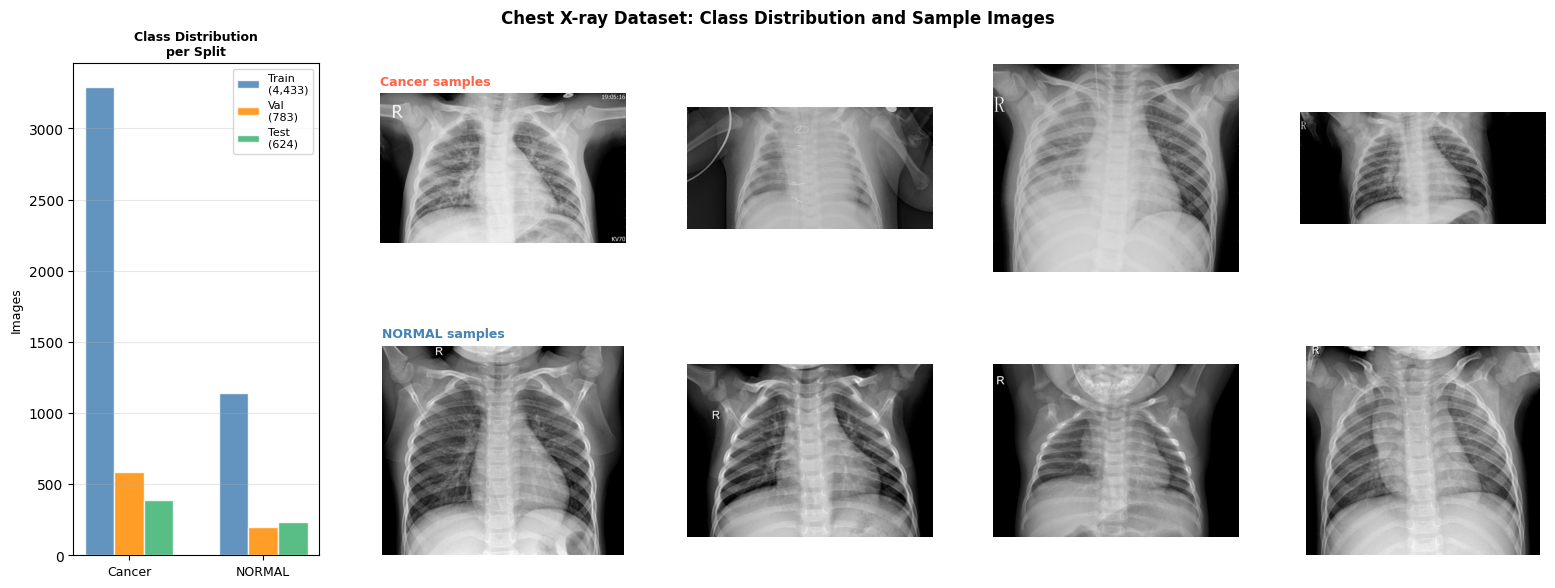

Train: Cancer=3293  NORMAL=1140  ratio=2.89:1
Val  : Cancer=582  NORMAL=201
Test : Cancer=390  NORMAL=234


In [139]:
# Class distribution + sample X-rays in one integrated figure
import matplotlib.gridspec as gridspec

cxr_labels_tr = np.array([lbl for _, lbl in cxr_train.samples])
cxr_labels_va = np.array([lbl for _, lbl in cxr_val.samples])
cxr_labels_te = np.array([lbl for _, lbl in cxr_test.samples])

# Raw dataset (no transform) so we can display original pixel values
raw_ds = ChestXrayCancerDataset(cxr_train.samples, transform=None)

idx_cancer = [i for i, (_, lbl) in enumerate(raw_ds.samples) if lbl == 1][:4]
idx_normal = [i for i, (_, lbl) in enumerate(raw_ds.samples) if lbl == 0][:4]

# Single figure: left = bar chart (full height),
# right = 2-row x 4-col image grid (Cancer top, NORMAL bottom)
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Chest X-ray Dataset: Class Distribution and Sample Images",
             fontsize=12, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 5, figure=fig,
                       left=0.06, right=0.98, top=0.92, bottom=0.10,
                       wspace=0.25, hspace=0.35)

# Left panel: grouped bar chart spanning both rows
ax_bar = fig.add_subplot(gs[:, 0])

split_data = [
    ("Train\n(4,433)", cxr_labels_tr, "steelblue"),
    ("Val\n(783)",     cxr_labels_va, "darkorange"),
    ("Test\n(624)",    cxr_labels_te, "mediumseagreen"),
]
bar_x = np.arange(2)
bar_w = 0.22
for k, (split_name, labels, color) in enumerate(split_data):
    n_cancer = (labels == 1).sum()
    n_normal = (labels == 0).sum()
    ax_bar.bar(bar_x + k * bar_w, [n_cancer, n_normal], bar_w,
               label=split_name, color=color, alpha=0.85, edgecolor="white")

ax_bar.set_xticks(bar_x + bar_w)
ax_bar.set_xticklabels(["Cancer", "NORMAL"], fontsize=9)
ax_bar.set_ylabel("Images", fontsize=9)
ax_bar.set_title("Class Distribution\nper Split", fontsize=9, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.grid(axis="y", alpha=0.3)

# Right panels: Cancer (row 0) + NORMAL (row 1), 4 images each
row_cfg = [("Cancer", idx_cancer, "tomato"), ("NORMAL", idx_normal, "steelblue")]
for row, (class_name, indices, title_color) in enumerate(row_cfg):
    for col, idx in enumerate(indices):
        ax = fig.add_subplot(gs[row, col + 1])
        img, _ = raw_ds[idx]          # PIL image (no transform)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"{class_name} samples", fontsize=9,
                         color=title_color, fontweight="bold", loc="left")

plt.savefig(os.path.join(FIG_DIR, f"cxr_explore_{RUN_ID}.png"), dpi=200,
            bbox_inches="tight")
plt.show()

print(f"Train: Cancer={int((cxr_labels_tr==1).sum())}  NORMAL={int((cxr_labels_tr==0).sum())}  "
      f"ratio={int((cxr_labels_tr==1).sum())/int((cxr_labels_tr==0).sum()):.2f}:1")
print(f"Val  : Cancer={int((cxr_labels_va==1).sum())}  NORMAL={int((cxr_labels_va==0).sum())}")
print(f"Test : Cancer={int((cxr_labels_te==1).sum())}  NORMAL={int((cxr_labels_te==0).sum())}")

### Model Initialisation

Pretrained ResNet-18 backbone with a 1-channel grayscale adaptation. Differential learning rates allow the backbone to fine-tune slowly while the new classification head learns faster.

In [140]:
small_model = CXRClassifier(dropout_p=0.5, pretrained=True).to(device)

def cxr_smooth_bce(logits, y, pos_weight, eps=0.05):
    y_s = y.float() * (1 - eps) + eps / 2
    return F.binary_cross_entropy_with_logits(logits, y_s,
                                               pos_weight=pos_weight, reduction="mean")

small_criterion = lambda logits, y: cxr_smooth_bce(logits, y, small_pos_weight)

backbone_params = list(small_model.features.parameters())
head_params     = list(small_model.fc.parameters()) + list(small_model.drop.parameters())

small_optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params,     "lr": 5e-4},
], weight_decay=1e-4)

small_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    small_optimizer, T_max=30, eta_min=1e-6
)

n_total = sum(p.numel() for p in small_model.parameters())
print(f"CXRClassifier: {n_total:,} params  (~{n_total/1e6:.2f} M)")
print(f"Loss  : label-smoothed BCE (eps=0.05)  pos_weight={small_pos_weight.item():.3f}")
print(f"LR    : backbone=1e-4  head=5e-4  (differential fine-tuning)")
print("Natural distribution (no sampler), temperature scaling post-train")


CXRClassifier: 11,170,753 params  (~11.17 M)
Loss  : label-smoothed BCE (eps=0.05)  pos_weight=0.346
LR    : backbone=1e-4  head=5e-4  (differential fine-tuning)
Natural distribution (no sampler), temperature scaling post-train


### CXRClassifier Training

Fine-tunes the ResNet-18 backbone with differential learning rates. The model
trains on the natural class distribution with early stopping on val AUROC;
best weights are reloaded after training.


In [141]:
print("=" * 60)
print("Training Model 3: CXRClassifier  (Chest X-ray)")
print("=" * 60)
print("Natural distribution training (no WeightedRandomSampler).")

small_history    = {"train_loss": [], "val_loss": [], "val": []}
small_best_score = -1.0
small_best_epoch = -1
patience_cxr     = 0
CXR_MAX_EPOCHS   = 30

for epoch in range(1, CXR_MAX_EPOCHS + 1):
    t_loss = train_one_epoch(small_model, small_train_loader,
                              small_optimizer, small_criterion, device)
    v_loss = evaluate_loss(small_model, small_val_loader, small_criterion, device)
    v_met  = evaluate(small_model, small_val_loader, device,
                      threshold=cfg.threshold, criterion=small_criterion)
    v_met["val_loss"] = v_loss
    small_scheduler.step()

    auroc = f"{v_met['auroc']:.4f}" if v_met["auroc"] else "N/A"
    print(f"epoch {epoch:02d}/{CXR_MAX_EPOCHS} | train {t_loss:.4f} | val {v_loss:.4f} | "
          f"auroc {auroc} | f1 {v_met['f1']:.4f} | "
          f"lr_backbone {small_optimizer.param_groups[0]['lr']:.2e}")

    small_history["train_loss"].append(t_loss)
    small_history["val_loss"].append(v_loss)
    small_history["val"].append(v_met)

    score = v_met["auroc"] if v_met["auroc"] else v_met["f1"]
    if score > small_best_score:
        small_best_score = score; small_best_epoch = epoch; patience_cxr = 0
        save_checkpoint(os.path.join(RUN_DIR, "best_small.pt"),
                        small_model, small_optimizer, epoch,
                        {"val_metrics": v_met, "config": cfg.__dict__})
    else:
        patience_cxr += 1
        if patience_cxr >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}  (patience={EARLY_STOP_PATIENCE})")
            break

ckpt = torch.load(os.path.join(RUN_DIR, "best_small.pt"), map_location=device)
small_model.load_state_dict(ckpt["model_state"])
print(f"Loaded best CXRClassifier from epoch {small_best_epoch}")

with open(metrics_path, "r") as f: m_all = json.load(f)
m_all["small_history"]    = small_history
m_all["small_best_epoch"] = small_best_epoch
with open(metrics_path, "w") as f: json.dump(m_all, f, indent=2)

print(f"\nCXRClassifier done.  Best epoch: {small_best_epoch}  Val AUROC: {small_best_score:.4f}")


Training Model 3: CXRClassifier  (Chest X-ray)
Natural distribution training (no WeightedRandomSampler).


epoch 01/30 | train 0.1437 | val 0.1246 | auroc 0.9977 | f1 0.9561 | lr_backbone 9.97e-05


epoch 02/30 | train 0.1213 | val 0.1225 | auroc 0.9974 | f1 0.9599 | lr_backbone 9.89e-05


epoch 03/30 | train 0.1076 | val 0.1025 | auroc 0.9985 | f1 0.9817 | lr_backbone 9.76e-05


epoch 04/30 | train 0.1083 | val 0.1036 | auroc 0.9987 | f1 0.9835 | lr_backbone 9.57e-05


...

epoch 26/30 | train 0.0833 | val 0.0931 | auroc 0.9994 | f1 0.9931 | lr_backbone 5.28e-06


epoch 27/30 | train 0.0837 | val 0.0929 | auroc 0.9994 | f1 0.9931 | lr_backbone 3.42e-06


epoch 28/30 | train 0.0835 | val 0.0932 | auroc 0.9993 | f1 0.9922 | lr_backbone 2.08e-06


epoch 29/30 | train 0.0831 | val 0.0934 | auroc 0.9994 | f1 0.9914 | lr_backbone 1.27e-06


epoch 30/30 | train 0.0833 | val 0.0932 | auroc 0.9994 | f1 0.9931 | lr_backbone 1.00e-06
Loaded best CXRClassifier from epoch 21

CXRClassifier done.  Best epoch: 21  Val AUROC: 0.9995


### CXR Temperature Scaling Calibration

Post-hoc temperature scaling calibrates the model's probability outputs without
retraining. A single scalar T is optimised on the validation logits:

    p_calibrated = sigmoid(logit / T)

T > 1 softens the distribution (moves probabilities toward 0.5), correcting
overconfidence. T < 1 sharpens the distribution, correcting underconfidence.
Calibration allows the threshold sweep to select a clinically interpretable
operating point.


In [142]:
# Temperature scaling for CXRClassifier
# Collect raw val logits from the trained model
y_val_raw, logits_val_raw = get_logits_and_labels(small_model, small_val_loader, device)

# Optimise T* via scipy bounded minimisation of BCE NLL
cxr_temperature = calibrate_temperature(logits_val_raw, y_val_raw)
logits_val_calibrated = logits_val_raw / cxr_temperature

print(f"CXR temperature T* = {cxr_temperature:.4f}")
if cxr_temperature > 1:
    print(f"  T > 1: model was overconfident — probabilities softened")
else:
    print(f"  T < 1: model was underconfident — probabilities sharpened")

# Quick sanity check: compare raw vs calibrated prob distributions
probs_raw  = sigmoid(logits_val_raw)
probs_cal  = sigmoid(logits_val_calibrated)
print(f"  Val probs (raw) : mean={probs_raw.mean():.3f}  std={probs_raw.std():.3f}")
print(f"  Val probs (cal) : mean={probs_cal.mean():.3f}  std={probs_cal.std():.3f}")


CXR temperature T* = 0.5025
  T < 1: model was underconfident — probabilities sharpened
  Val probs (raw) : mean=0.689  std=0.399
  Val probs (cal) : mean=0.734  std=0.432


### CXRClassifier Training Curves

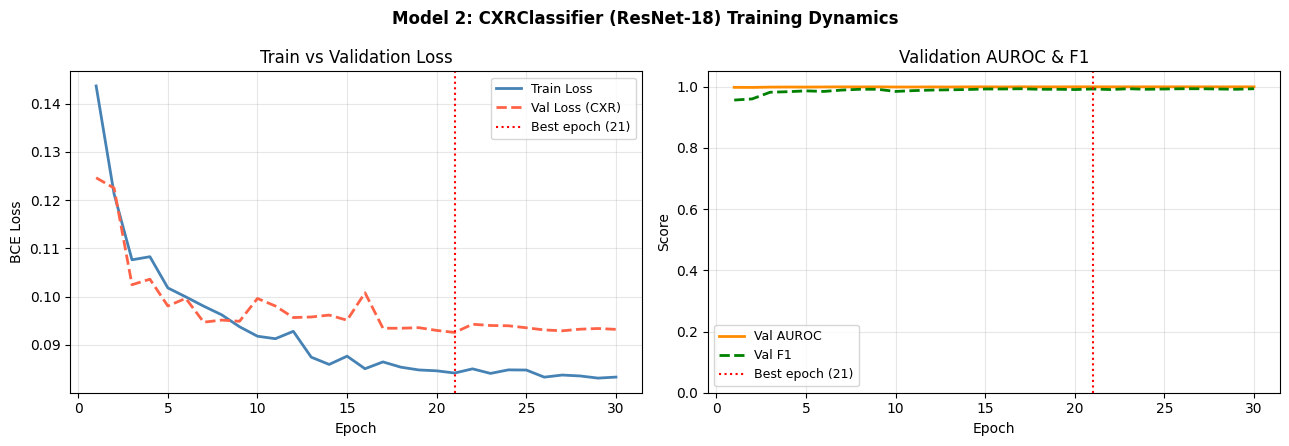

In [143]:
s_train = small_history["train_loss"]
s_val   = small_history["val_loss"]
s_auroc = [v["auroc"] for v in small_history["val"]]
s_f1    = [v["f1"]    for v in small_history["val"]]
s_ep    = range(1, len(s_train) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Model 2: CXRClassifier (ResNet-18) Training Dynamics", fontsize=12, fontweight="bold")

axes[0].plot(s_ep, s_train, label="Train Loss",    color="steelblue", linewidth=2)
axes[0].plot(s_ep, s_val,   label="Val Loss (CXR)", color="tomato", linestyle="--", linewidth=2)
axes[0].axvline(small_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({small_best_epoch})")
axes[0].set_title("Train vs Validation Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(s_ep, s_auroc, label="Val AUROC", color="darkorange", linewidth=2)
axes[1].plot(s_ep, s_f1,    label="Val F1",    color="green", linestyle="--", linewidth=2)
axes[1].axvline(small_best_epoch, color="red", linestyle=":", linewidth=1.5,
                label=f"Best epoch ({small_best_epoch})")
axes[1].set_title("Validation AUROC & F1"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score"); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"cxr_train_curves_{RUN_ID}.png"), dpi=200)
plt.show()


### CXRClassifier Threshold Tuning & ROC (Internal CXR Val)

CXRClassifier CXR val (calibrated) → best thr: 0.25  (F1=0.994  Recall=0.993  Precision=0.995  Spec=0.985)


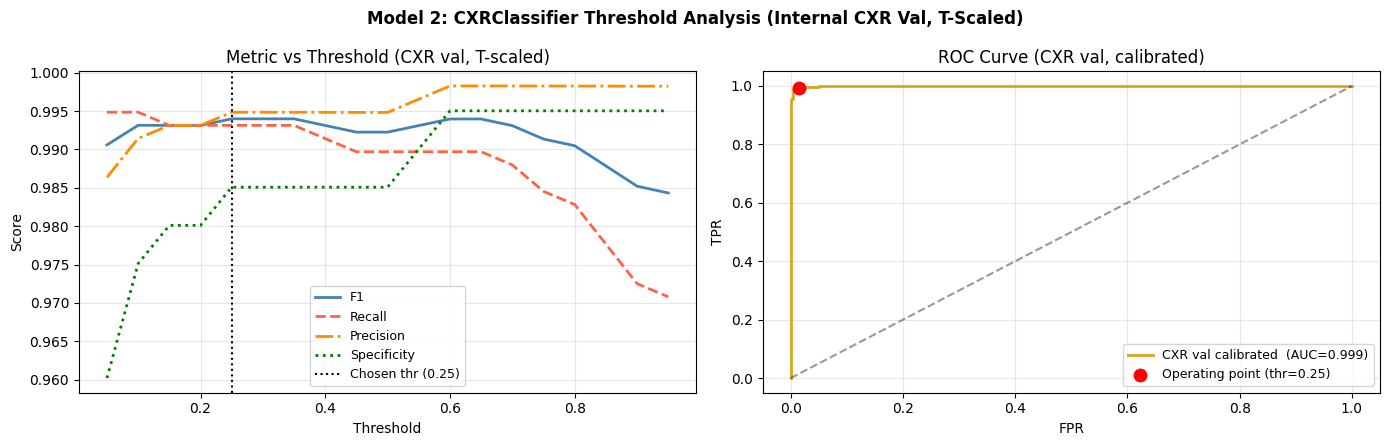

In [144]:
# Use temperature-calibrated logits for the threshold sweep.
# calibrated_logits = raw_logits / T* (already computed above)
y_val_small      = y_val_raw
logits_val_small = logits_val_calibrated   # calibrated

thresholds = np.linspace(0.05, 0.95, 19)
best_small_thresh_row = None
sweep_rows_small = []

for t in thresholds:
    met = compute_binary_metrics(y_val_small, logits_val_small, threshold=float(t))
    row = {"threshold": float(t), **{k: met[k] for k in
           ["f1", "recall", "precision", "specificity", "accuracy", "auroc"]}}
    sweep_rows_small.append(row)
    if best_small_thresh_row is None or row["f1"] > best_small_thresh_row["f1"]:
        best_small_thresh_row = row

small_threshold = best_small_thresh_row["threshold"]
print(f"CXRClassifier CXR val (calibrated) → best thr: {small_threshold:.2f}  "
      f"(F1={best_small_thresh_row['f1']:.3f}  "
      f"Recall={best_small_thresh_row['recall']:.3f}  "
      f"Precision={best_small_thresh_row['precision']:.3f}  "
      f"Spec={best_small_thresh_row['specificity']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Model 2: CXRClassifier Threshold Analysis (Internal CXR Val, T-Scaled)",
             fontsize=12, fontweight="bold")

thr_vals = [r["threshold"] for r in sweep_rows_small]
for metric, color, ls in [("f1","steelblue","-"), ("recall","tomato","--"),
                           ("precision","darkorange","-."), ("specificity","green",":")]:
    axes[0].plot(thr_vals, [r[metric] for r in sweep_rows_small],
                 label=metric.capitalize(), color=color, linestyle=ls, linewidth=2)
axes[0].axvline(small_threshold, color="black", linestyle=":", linewidth=1.5,
                label=f"Chosen thr ({small_threshold:.2f})")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Metric vs Threshold (CXR val, T-scaled)")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

probs_small = sigmoid(logits_val_small)
fpr_s, tpr_s, _ = sk_roc_curve(y_val_small, probs_small)
auc_s = float(np.trapezoid(tpr_s, fpr_s))

axes[1].plot(fpr_s, tpr_s, color="goldenrod", linewidth=2,
             label=f"CXR val calibrated  (AUC={auc_s:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].scatter([1 - best_small_thresh_row["specificity"]],
                [best_small_thresh_row["recall"]],
                color="red", zorder=5, s=80,
                label=f"Operating point (thr={small_threshold:.2f})")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve (CXR val, calibrated)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"cxr_threshold_roc_{RUN_ID}.png"), dpi=200)
plt.show()


### CXRClassifier Test Evaluation

Evaluated on the held-out `test/` folder (624 images: 390 Cancer, 234 NORMAL)
at the threshold tuned on the internal CXR validation split.


In [145]:
# Apply temperature scaling to test logits before evaluation
@torch.no_grad()
def get_calibrated_eval(model, loader, device, temperature, threshold):
    """Evaluate with temperature-scaled logits."""
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu().numpy())
        all_y.append(y.numpy().reshape(-1))
    raw_logits = np.concatenate(all_logits)
    cal_logits = raw_logits / temperature
    y_true     = np.concatenate(all_y).astype(int)
    return compute_binary_metrics(y_true, cal_logits, threshold=threshold)

cxr_test_small = get_calibrated_eval(small_model, cxr_test_loader, device,
                                      cxr_temperature, small_threshold)

print(f"Model 2 (CXRClassifier, Chest X-ray) test results  "
      f"[T*={cxr_temperature:.3f}  thr={small_threshold:.2f}]")
print(f"{'Dataset':22s}  {'AUROC':>6}  {'F1':>6}  {'Recall':>6}  {'Prec':>6}  {'Spec':>6}  {'Acc':>6}")
print("  " + "-" * 65)
for name, m in [("Chest X-ray (CXR)", cxr_test_small)]:
    def _f(v): return f"{v:.3f}" if v is not None else "N/A"
    print(f"  {name:22s}  {_f(m['auroc']):>6}  {_f(m['f1']):>6}  "
          f"{_f(m['recall']):>6}  {_f(m['precision']):>6}  "
          f"{_f(m['specificity']):>6}  {_f(m['accuracy']):>6}")


Model 2 (CXRClassifier, Chest X-ray) test results  [T*=0.503  thr=0.25]
Dataset                  AUROC      F1  Recall    Prec    Spec     Acc
  -----------------------------------------------------------------
  Chest X-ray (CXR)        0.889   0.883   0.997   0.792   0.564   0.835


### External CXR Generalization Evaluation (Optional)

To test CXRClassifier generalization on an independent dataset, point
`EXTERNAL_CXR_ROOT` to a folder with `Cancer/` and `NORMAL/` sub-folders.
If the path does not exist the cell prints a message and skips gracefully.

In [146]:
# External CXR dataset evaluation (point to your data folder)
# Supported structure:  <EXTERNAL_CXR_ROOT>/Cancer/*.jpg  and  .../NORMAL/*.jpg
EXTERNAL_CXR_ROOT = os.path.join(REPO_ROOT, "data", "external_cxr")

if os.path.isdir(EXTERNAL_CXR_ROOT):
    import torchvision.transforms as tvT
    ext_eval_transform = tvT.Compose([
        tvT.Grayscale(num_output_channels=1),
        tvT.Resize((224, 224)),
        tvT.ToTensor(),
        tvT.Normalize(mean=[0.5], std=[0.5]),
    ])
    ext_samples = ChestXrayCancerDataset.collect_samples(EXTERNAL_CXR_ROOT, split=None)
    if ext_samples:
        ext_ds     = ChestXrayCancerDataset(ext_samples, transform=ext_eval_transform)
        ext_loader = DataLoader(ext_ds, batch_size=32, shuffle=False,
                                collate_fn=cxr_collate_fn,
                                num_workers=cfg.num_workers)
        ext_results = get_calibrated_eval(small_model, ext_loader, device,
                                           cxr_temperature, small_threshold)
        print("External CXR results:")
        for k, v in ext_results.items():
            if v is not None:
                print(f"  {k:15s}: {v:.4f}")
    else:
        print(f"No images found in {EXTERNAL_CXR_ROOT}. Skipping.")
else:
    print(f"External CXR dataset not found at: {EXTERNAL_CXR_ROOT}")
    print("To evaluate, add a folder with Cancer/ and NORMAL/ sub-folders at that path.")


External CXR dataset not found at: /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/data/external_cxr
To evaluate, add a folder with Cancer/ and NORMAL/ sub-folders at that path.


---

## Model 2: LUNA3DCNN (LUNA16 Nodule-Presence Detection)

**Task:** Binary classification of 32x32x32 CT patches — confirmed nodule (1)
vs. randomly sampled background tissue (0). This is a detection task, not
malignancy classification. The features are macroscopic (a dense spherical
structure against uniform parenchyma), so a compact 3-stage model is sufficient.

**Architecture:** 3 residual stages with standard ResBlock3D (no SE attention),
MaxPool after each stage, GAP -> Dropout(0.3) -> FC(256->1). ~2.0 M params.

**Training:** Standard cross-entropy with pos_weight, cosine LR schedule,
early stopping on val AUROC. No WeightedRandomSampler (classes are balanced in LUNA16).


In [147]:
luna_model = LUNA3DCNN(dropout_p=0.3).to(device)

luna_criterion = lambda logits, y: F.binary_cross_entropy_with_logits(
    logits, y.float().view(-1), pos_weight=luna_pos_weight
)

luna_optimizer = torch.optim.AdamW(luna_model.parameters(),
                                   lr=cfg.lr, weight_decay=cfg.weight_decay)
luna_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    luna_optimizer, T_max=cfg.epochs, eta_min=1e-6
)

n_luna = sum(p.numel() for p in luna_model.parameters())
print(f"LUNA3DCNN  : {n_luna:,} params  (~{n_luna/1e6:.2f} M)")
print(f"Loss       : BCE  pos_weight={luna_pos_weight.item():.3f}")


LUNA3DCNN  : 3,530,529 params  (~3.53 M)
Loss       : BCE  pos_weight=2.171


In [148]:
print("=" * 60)
print("Training Model 2: LUNA3DCNN  (LUNA16)")
print("=" * 60)

luna_history   = {"train_loss": [], "val_loss": [], "val": []}
luna_best_score = -1.0
luna_best_epoch = -1
patience_luna   = 0

for epoch in range(1, cfg.epochs + 1):
    t_loss = train_one_epoch(luna_model, luna_train_loader,
                              luna_optimizer, luna_criterion, device)
    v_loss = evaluate_loss(luna_model, luna_val_loader, luna_criterion, device)
    v_met  = evaluate(luna_model, luna_val_loader, device,
                      threshold=cfg.threshold, criterion=luna_criterion)
    v_met["val_loss"] = v_loss
    luna_scheduler.step()

    auroc = f"{v_met['auroc']:.4f}" if v_met["auroc"] else "N/A"
    print(f"epoch {epoch:02d}/{cfg.epochs} | train {t_loss:.4f} | val {v_loss:.4f} | "
          f"auroc {auroc} | f1 {v_met['f1']:.4f} | "
          f"lr {luna_optimizer.param_groups[0]['lr']:.2e}")

    luna_history["train_loss"].append(t_loss)
    luna_history["val_loss"].append(v_loss)
    luna_history["val"].append(v_met)

    score = v_met["auroc"] if v_met["auroc"] else v_met["f1"]
    if score > luna_best_score:
        luna_best_score = score; luna_best_epoch = epoch; patience_luna = 0
        save_checkpoint(os.path.join(RUN_DIR, "best_luna.pt"),
                        luna_model, luna_optimizer, epoch,
                        {"val_metrics": v_met, "config": cfg.__dict__})
    else:
        patience_luna += 1
        if patience_luna >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

ckpt = torch.load(os.path.join(RUN_DIR, "best_luna.pt"), map_location=device)
luna_model.load_state_dict(ckpt["model_state"])
print(f"Loaded best LUNA3DCNN from epoch {luna_best_epoch}")

with open(metrics_path, "r") as f: m_all = json.load(f)
m_all["luna_history"]    = luna_history
m_all["luna_best_epoch"] = luna_best_epoch
with open(metrics_path, "w") as f: json.dump(m_all, f, indent=2)
print(f"\nLUNA3DCNN done.  Best epoch: {luna_best_epoch}  Val AUROC: {luna_best_score:.4f}")


Training Model 2: LUNA3DCNN  (LUNA16)


epoch 01/60 | train 0.9803 | val 1.0428 | auroc 0.5785 | f1 0.4825 | lr 3.00e-04


epoch 02/60 | train 0.8848 | val 0.9084 | auroc 0.6813 | f1 0.5052 | lr 2.99e-04


epoch 03/60 | train 0.8153 | val 0.8639 | auroc 0.7775 | f1 0.5403 | lr 2.98e-04


epoch 04/60 | train 0.7715 | val 0.8671 | auroc 0.7878 | f1 0.5000 | lr 2.97e-04


...

epoch 52/60 | train 0.0682 | val 0.2561 | auroc 0.9835 | f1 0.8819 | lr 1.39e-05


epoch 53/60 | train 0.0882 | val 0.2495 | auroc 0.9830 | f1 0.8819 | lr 1.09e-05


epoch 54/60 | train 0.0606 | val 0.2608 | auroc 0.9819 | f1 0.8871 | lr 8.32e-06


epoch 55/60 | train 0.0726 | val 0.2531 | auroc 0.9821 | f1 0.8960 | lr 6.09e-06


epoch 56/60 | train 0.0776 | val 0.2483 | auroc 0.9828 | f1 0.9048 | lr 4.27e-06
Early stopping at epoch 56
Loaded best LUNA3DCNN from epoch 46

LUNA3DCNN done.  Best epoch: 46  Val AUROC: 0.9881


### LUNA3DCNN Threshold Tuning & ROC


LUNA3DCNN val -> best thr: 0.55  (F1=0.919  Recall=0.919  Prec=0.919  Spec=0.962)


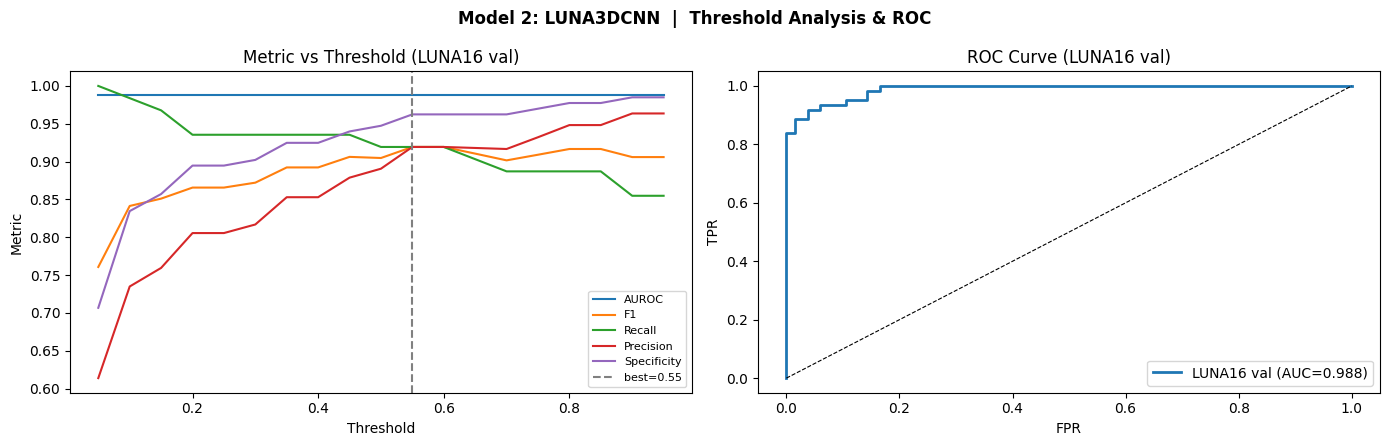

In [149]:
thresholds_l = np.linspace(0.05, 0.95, 19)
sweep_rows_l = []
for thr in thresholds_l:
    m = evaluate(luna_model, luna_val_loader, device, threshold=float(thr))
    sweep_rows_l.append((thr, m["auroc"], m["f1"], m["recall"], m["precision"], m["specificity"]))

best_luna_row  = max(sweep_rows_l, key=lambda r: r[2])
luna_threshold = float(best_luna_row[0])
print(f"LUNA3DCNN val -> best thr: {luna_threshold:.2f}  "
      f"(F1={best_luna_row[2]:.3f}  Recall={best_luna_row[3]:.3f}  "
      f"Prec={best_luna_row[4]:.3f}  Spec={best_luna_row[5]:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Model 2: LUNA3DCNN  |  Threshold Analysis & ROC", fontweight="bold")

ax = axes[0]
labels_l = ["AUROC","F1","Recall","Precision","Specificity"]
colors_l  = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]
thrs_arr  = [r[0] for r in sweep_rows_l]
for col, (lab, col_c) in enumerate(zip(labels_l, colors_l), start=1):
    ax.plot(thrs_arr, [r[col] for r in sweep_rows_l], label=lab, color=col_c)
ax.axvline(luna_threshold, linestyle="--", color="gray", label=f"best={luna_threshold:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Metric"); ax.legend(fontsize=8)
ax.set_title("Metric vs Threshold (LUNA16 val)")

ax2 = axes[1]
@torch.no_grad()
def _get_logits(model, loader, dev):
    model.eval()
    ls, ys = [], []
    from tqdm import tqdm
    for x, y in tqdm(loader, desc="roc", leave=False):
        ls.append(model(x.to(dev)).cpu().numpy())
        ys.append(y.numpy().reshape(-1))
    return np.concatenate(ls), np.concatenate(ys).astype(int)

lgt_l, y_l = _get_logits(luna_model, luna_val_loader, device)
fpr_l, tpr_l, _ = sk_roc_curve(y_l, lgt_l)
auc_l = compute_binary_metrics(y_l, lgt_l, threshold=luna_threshold)["auroc"]
ax2.plot(fpr_l, tpr_l, lw=2, label=f"LUNA16 val (AUC={auc_l:.3f})")
ax2.plot([0,1],[0,1],"k--",lw=0.8)
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR"); ax2.legend()
ax2.set_title("ROC Curve (LUNA16 val)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"luna3d_threshold_roc_{RUN_ID}.png"), dpi=150, bbox_inches="tight")
plt.show()

with open(metrics_path, "r") as f: m_all = json.load(f)
m_all["luna_threshold"] = luna_threshold
with open(metrics_path, "w") as f: json.dump(m_all, f, indent=2)


### LUNA3DCNN Training Curves


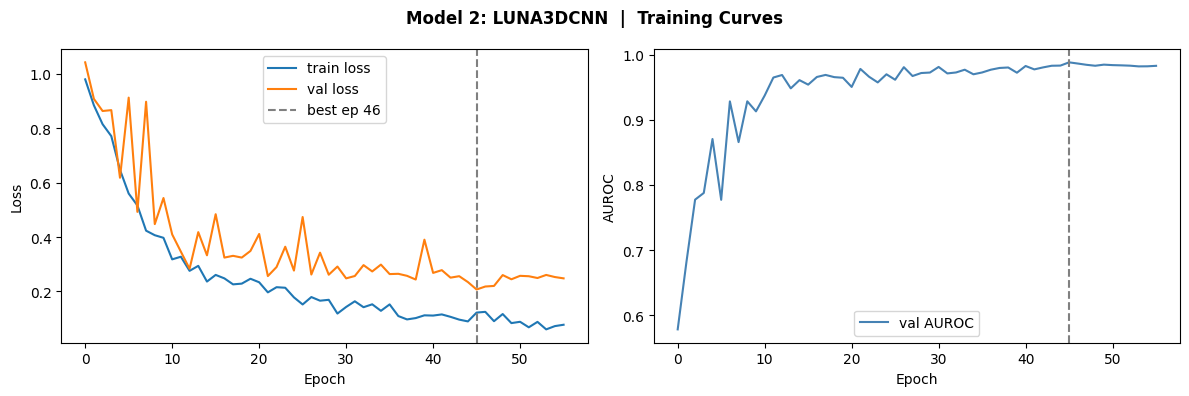

In [150]:
l_train = luna_history["train_loss"]
l_val   = luna_history["val_loss"]
l_auroc = [v["auroc"] for v in luna_history["val"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model 2: LUNA3DCNN  |  Training Curves", fontweight="bold")
axes[0].plot(l_train, label="train loss"); axes[0].plot(l_val, label="val loss")
axes[0].axvline(luna_best_epoch-1, color="gray", linestyle="--", label=f"best ep {luna_best_epoch}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].plot(l_auroc, color="steelblue", label="val AUROC")
axes[1].axvline(luna_best_epoch-1, color="gray", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUROC"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"luna3d_train_curves_{RUN_ID}.png"), dpi=150, bbox_inches="tight")
plt.show()


### LUNA3DCNN Test Evaluation


In [151]:
luna16_test_deep = evaluate(luna_model, luna16_test_loader, device, threshold=luna_threshold)

print(f"Model 2 (LUNA3DCNN) test results  [thr={luna_threshold:.2f}]")
def _fv(v): return f"{v:.3f}" if v is not None else "N/A"
m = luna16_test_deep
print(f"  LUNA16  AUROC={_fv(m['auroc'])}  F1={_fv(m['f1'])}  "
      f"Recall={_fv(m['recall'])}  Prec={_fv(m['precision'])}  "
      f"Spec={_fv(m['specificity'])}  Acc={_fv(m['accuracy'])}")

with open(metrics_path, "r") as f: m_all = json.load(f)
m_all["test_luna16_luna3d"] = luna16_test_deep
with open(metrics_path, "w") as f: json.dump(m_all, f, indent=2)


Model 2 (LUNA3DCNN) test results  [thr=0.55]
  LUNA16  AUROC=0.991  F1=0.934  Recall=0.934  Prec=0.934  Spec=0.970  Acc=0.959


---

## Combined Results

Unified performance reporting across all three models and datasets.
Each model is evaluated exclusively on the dataset it was trained for,
ensuring the reported metrics reflect real-world deployment conditions.

| Model | Dataset | Threshold tuned on |
|---|---|---|
| Deep3DCNN | NoduleMNIST3D | NoduleMNIST3D validation split |
| LUNA3DCNN | LUNA16 | LUNA16 validation split |
| CXRClassifier | Chest X-ray | Internal CXR validation split |


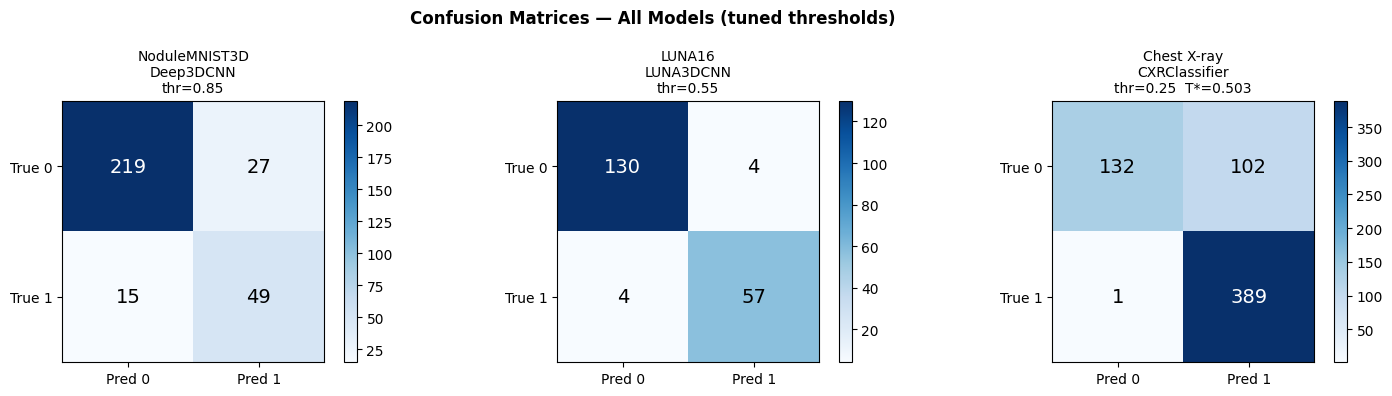

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices — All Models (tuned thresholds)", fontweight="bold")
result_triples = [
    (f"NoduleMNIST3D\nDeep3DCNN",   nodule_test_deep, f"thr={deep_threshold:.2f}"),
    (f"LUNA16\nLUNA3DCNN",          luna16_test_deep, f"thr={luna_threshold:.2f}"),
    (f"Chest X-ray\nCXRClassifier", cxr_test_small,  f"thr={small_threshold:.2f}  T*={cxr_temperature:.3f}"),
]
for ax, (title, m, note) in zip(axes, result_triples):
    cm = np.array(m["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    for r in range(2):
        for c_ in range(2):
            ax.text(c_, r, str(cm[r, c_]), ha="center", va="center",
                    color="white" if cm[r, c_] > cm.max()/2 else "black", fontsize=14)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred 0","Pred 1"]); ax.set_yticklabels(["True 0","True 1"])
    ax.set_title(f"{title}\n{note}", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"confusion_matrices_tuned_{RUN_ID}.png"), dpi=150, bbox_inches="tight")
plt.show()


In [153]:
dataset_results_all = [
    ("NoduleMNIST3D", "Deep3DCNN",     nodule_test_deep),
    ("LUNA16",        "LUNA3DCNN",     luna16_test_deep),
    ("Chest X-ray",   "CXRClassifier", cxr_test_small),
]
print(f"{'Dataset':20s}  {'Model':15s}  {'AUROC':>6}  {'F1':>6}  {'Recall':>6}  {'Prec':>6}  {'Spec':>6}  {'Acc':>6}")
print("-" * 90)
for (ds, mdl, m) in dataset_results_all:
    def _f(v): return f"{v:.3f}" if v is not None else "N/A"
    print(f"{ds:20s}  {mdl:15s}  {_f(m['auroc']):>6}  {_f(m['f1']):>6}  "
          f"{_f(m['recall']):>6}  {_f(m['precision']):>6}  "
          f"{_f(m['specificity']):>6}  {_f(m['accuracy']):>6}")


Dataset               Model             AUROC      F1  Recall    Prec    Spec     Acc
------------------------------------------------------------------------------------------
NoduleMNIST3D         Deep3DCNN         0.906   0.700   0.766   0.645   0.890   0.865
LUNA16                LUNA3DCNN         0.991   0.934   0.934   0.934   0.970   0.959
Chest X-ray           CXRClassifier     0.889   0.883   0.997   0.792   0.564   0.835


## Logistic Regression Baseline
### Flattened voxels, NoduleMNIST3D only

In [154]:
# Trained on the same NoduleMNIST3D train/val/test split used across all trials.
def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        X.append(np.array(x_i).astype(np.float32).reshape(-1))
        y.append(int(np.array(y_i).reshape(-1)[0]))
    return np.stack(X), np.array(y)

X_train_lr, y_train_lr = flatten_dataset(train_ds)
X_test_lr,  y_test_lr  = flatten_dataset(test_ds)

clf = make_pipeline(StandardScaler(),
                    LogisticRegression(max_iter=2000, class_weight="balanced"))
clf.fit(X_train_lr, y_train_lr)

lr_metrics = compute_binary_metrics(y_test_lr, clf.decision_function(X_test_lr), threshold=0.5)
print("LogReg baseline (NoduleMNIST3D test, thr=0.50):")
for k, v in lr_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all.update({
    "deep_threshold":       deep_threshold,
    "small_threshold":      small_threshold,
    "test_nodule_deep":     nodule_test_deep,
    "test_luna16_deep":     luna16_test_deep,
    "test_cxr_small":       cxr_test_small,
    "logreg_baseline_test": lr_metrics,
})
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)


LogReg baseline (NoduleMNIST3D test, thr=0.50):
  auroc: 0.823
  f1: 0.538
  accuracy: 0.806
  precision: 0.530
  recall: 0.547
  specificity: 0.874


## Results Summary

Final performance table across all three models and datasets.

- **Blue rows:** Deep3DCNN on NoduleMNIST3D (3D malignancy classification)
- **Green rows:** LUNA3DCNN on LUNA16 (3D nodule-presence detection)
- **Orange rows:** CXRClassifier on Chest X-ray (2D cancer screening)
- **Grey rows:** Logistic Regression baseline (NoduleMNIST3D flat voxels)
- **Gold cells:** best value per metric column across the three main models


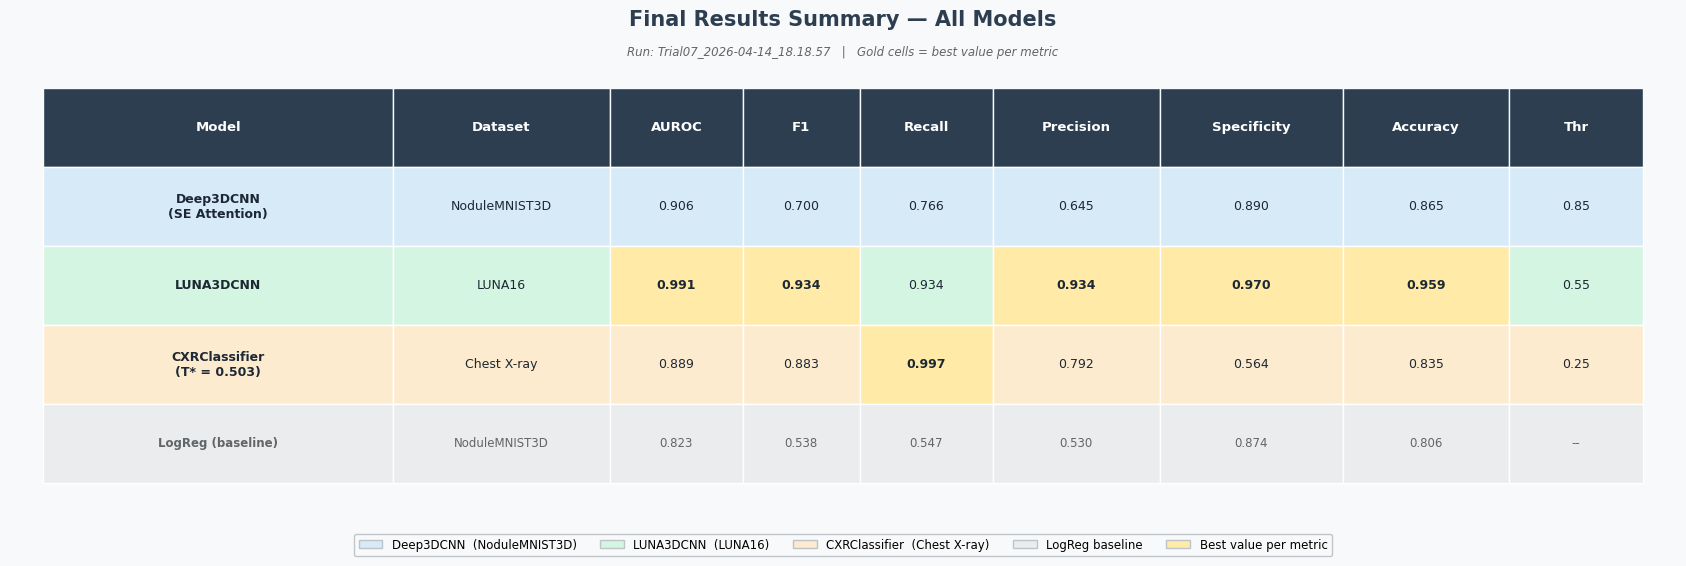

Metrics saved to /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/results/runs/Trial07_2026-04-14_18.18.57/metrics.json


In [155]:
# Colour palette
C_DEEP  = '#D6EAF8'   # soft blue   — Deep3DCNN
C_LUNA  = '#D5F5E3'   # soft green  — LUNA3DCNN
C_CXR   = '#FDEBD0'   # soft orange — CXRClassifier
C_BASE  = '#EAECEE'   # soft grey   — LogReg baseline
C_HDR   = '#2C3E50'   # dark navy   — header
C_BEST  = '#FFEAA7'   # warm gold   — best value per metric column
TXT_HDR  = 'white'
TXT_BODY = '#1C2833'
TXT_DIM  = '#626567'

# Row data (raw floats for numeric comparison, formatted when rendered)
COLS = ["Model", "Dataset", "AUROC", "F1", "Recall", "Precision", "Specificity", "Accuracy", "Thr"]
METRIC_CI = list(range(2, 8))

rows_raw = [
    [f"Deep3DCNN\n(SE Attention)",
     "NoduleMNIST3D",
     nodule_test_deep["auroc"], nodule_test_deep["f1"],
     nodule_test_deep["recall"], nodule_test_deep["precision"],
     nodule_test_deep["specificity"], nodule_test_deep["accuracy"],
     deep_threshold],
    ["LUNA3DCNN",
     "LUNA16",
     luna16_test_deep["auroc"], luna16_test_deep["f1"],
     luna16_test_deep["recall"], luna16_test_deep["precision"],
     luna16_test_deep["specificity"], luna16_test_deep["accuracy"],
     luna_threshold],
    [f"CXRClassifier\n(T* = {cxr_temperature:.3f})",
     "Chest X-ray",
     cxr_test_small["auroc"], cxr_test_small["f1"],
     cxr_test_small["recall"], cxr_test_small["precision"],
     cxr_test_small["specificity"], cxr_test_small["accuracy"],
     small_threshold],
    ["LogReg (baseline)",
     "NoduleMNIST3D",
     lr_metrics["auroc"], lr_metrics["f1"],
     lr_metrics["recall"], lr_metrics["precision"],
     lr_metrics["specificity"], lr_metrics["accuracy"],
     None],
]
N_ROWS = len(rows_raw)

# Find best value per metric column across the three main models
best = {}
for ci in METRIC_CI:
    vals = [rows_raw[ri][ci] for ri in range(3) if rows_raw[ri][ci] is not None]
    if vals:
        best[ci] = max(vals)

# Format cell text
def cell_txt(ri, ci):
    v = rows_raw[ri][ci]
    if v is None:         return "--"
    if ci in METRIC_CI:   return f"{v:.3f}"
    if ci == 8:           return f"{v:.2f}"
    return str(v)

cell_texts = [[cell_txt(ri, ci) for ci in range(len(COLS))] for ri in range(N_ROWS)]
row_bg     = [C_DEEP, C_LUNA, C_CXR, C_BASE]

# Per-cell colour: start from row colour, highlight best values in gold
cell_colors = [[row_bg[ri]] * len(COLS) for ri in range(N_ROWS)]
for ri in range(3):
    for ci in METRIC_CI:
        if ci in best and rows_raw[ri][ci] is not None:
            if abs(rows_raw[ri][ci] - best[ci]) < 1e-9:
                cell_colors[ri][ci] = C_BEST

fig = plt.figure(figsize=(17, 5.2))
fig.patch.set_facecolor('#F8F9FA')

fig.text(0.5, 0.97, "Final Results Summary — All Models",
         fontsize=15, fontweight='bold', ha='center', va='top',
         color=C_HDR)
fig.text(0.5, 0.90, f"Run: {RUN_ID}   |   Gold cells = best value per metric",
         fontsize=8.5, ha='center', va='top', color=TXT_DIM, style='italic')

ax = fig.add_axes([0.01, 0.06, 0.98, 0.76])
ax.axis('off')

tbl = ax.table(
    cellText=cell_texts,
    colLabels=COLS,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)

for ci in range(len(COLS)):
    cell = tbl[0, ci]
    cell.set_facecolor(C_HDR)
    cell.set_text_props(color=TXT_HDR, fontweight='bold', fontsize=9.5)
    cell.set_edgecolor('#F8F9FA')
    cell.set_height(0.20)

txt_colors = [TXT_BODY, TXT_BODY, TXT_BODY, TXT_DIM]
for ri in range(N_ROWS):
    for ci in range(len(COLS)):
        cell = tbl[ri + 1, ci]
        cell.set_edgecolor('#FFFFFF')
        is_best = (cell_colors[ri][ci] == C_BEST)
        cell.set_text_props(
            color=TXT_BODY if is_best else txt_colors[ri],
            fontsize=9.0 if ri < 3 else 8.5,
            fontweight='bold' if (is_best or ci == 0) else 'normal',
        )
        cell.set_height(0.20)

col_widths = [0.21, 0.13, 0.08, 0.07, 0.08, 0.10, 0.11, 0.10, 0.08]
for ci, w in enumerate(col_widths):
    tbl[0, ci].set_width(w)
    for ri in range(N_ROWS):
        tbl[ri + 1, ci].set_width(w)

legend_items = [
    mpatches.Patch(facecolor=C_DEEP, edgecolor='#BDC3C7', label='Deep3DCNN  (NoduleMNIST3D)'),
    mpatches.Patch(facecolor=C_LUNA, edgecolor='#BDC3C7', label='LUNA3DCNN  (LUNA16)'),
    mpatches.Patch(facecolor=C_CXR,  edgecolor='#BDC3C7', label='CXRClassifier  (Chest X-ray)'),
    mpatches.Patch(facecolor=C_BASE, edgecolor='#BDC3C7', label='LogReg baseline'),
    mpatches.Patch(facecolor=C_BEST, edgecolor='#BDC3C7', label='Best value per metric'),
]
ax.legend(handles=legend_items, loc='lower center',
          bbox_to_anchor=(0.5, -0.20), ncol=5,
          fontsize=8.5, frameon=True, framealpha=0.95,
          edgecolor='#BDC3C7', facecolor='#F8F9FA')

plt.savefig(os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png"),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# Persist all test metrics
with open(metrics_path, "r") as f: m_all = json.load(f)
m_all["test_nodule_deep"]     = nodule_test_deep
m_all["test_luna16_luna3d"]   = luna16_test_deep
m_all["test_cxr_small"]       = cxr_test_small
m_all["logreg_baseline_test"] = lr_metrics
with open(metrics_path, "w") as f: json.dump(m_all, f, indent=2)
print(f"Metrics saved to {metrics_path}")
